In [10]:
import pandas as pd
import json

# File path to your JSON data
file_path = "../Hyperparameters_search/save_it_here/intermediate_results_sampling.jsonl"  # Update with the actual file path
file_path = "../Hyperparameters_search/intermediate_results_sampling.jsonl"  # Update with the actual file path


# Read the JSON file line by line and store each JSON object in a list
data_list = []
with open(file_path, "r") as file:
    for line in file:
        data_list.append(json.loads(line.strip()))

# Normalize JSON data to a Pandas DataFrame
df = pd.json_normalize(data_list, sep='_')

# Display the DataFrame
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Hyperparameter Search Results", dataframe=df)

import numpy as np

# Deal with runs that haven't converged
df.loc[df["metrics_observed_rmse"] == 0, df.columns[df.columns.str.startswith("metrics_")]] = np.nan
df['Converged'] = (df.metrics_observed_rmse==df.metrics_observed_rmse)

metrics_mask = [('metrics' in elt) for elt in df.columns]
metrics = df.columns[metrics_mask]

df = df[df.training_time > 50]

df

,training_time,hyperparameters_alpha,hyperparameters_beta,hyperparameters_noise_sigma,hyperparameters_noise_std,hyperparameters_use_mean_z,hyperparameters_detach_flag,hyperparameters_sampling,metrics_observed_rmse,metrics_observed_nll,...,metrics_observed_coverage,metrics_observed_uncertainty_error_corr,metrics_missing_rmse,metrics_missing_nll,metrics_missing_elbo,metrics_missing_coverage,metrics_missing_uncertainty_error_corr,metrics_latent_latent_ks,metrics_reconstruction_overall_coverage,Converged
0,738.927845,0.1,1.0,0.005,0.05,True,True,True,0.012855,-3367.527962,...,0.998089,0.086021,0.607837,12326.184787,-173747.122287,0.605730,0.116107,0.547659,0.881435,True
1,900.738400,0.1,1.0,0.005,0.05,True,True,False,0.020278,-3332.304877,...,0.997348,0.059455,0.637530,14164.495352,-177498.120352,0.598650,-0.017320,0.590182,0.877037,True
2,48874.124437,0.1,1.0,0.005,0.05,True,True,True,0.017853,-3352.498408,...,0.993081,0.077089,0.676660,14327.965855,-163723.856480,0.315019,0.210218,0.680387,0.791389,True
3,14756.916769,0.1,1.0,0.005,0.05,True,True,False,0.011909,-3367.829156,...,0.996176,0.077529,0.731312,18454.417876,-180301.152251,0.582465,-0.199874,0.552087,0.872963,True
4,753.810712,0.1,1.0,0.005,0.05,True,False,True,0.014198,-3385.095903,...,0.996317,0.111637,0.693904,15989.743327,-137370.430827,0.558249,-0.037457,0.619219,0.866620,True
5,924.418705,0.1,1.0,0.005,0.05,True,False,False,0.022001,-3335.927358,...,0.990069,0.002497,0.657257,13402.432604,-159311.620104,0.302648,0.177068,0.576627,0.783333,True
6,693.344076,0.1,1.0,0.005,0.05,False,True,True,0.026643,-3355.484692,...,0.986003,0.088443,0.669719,13953.463780,-170482.620030,0.291915,0.191560,0.645612,0.780926,True
7,740.328755,0.1,1.0,0.005,0.05,False,True,False,0.011943,-3375.457121,...,0.997046,0.145252,0.708620,16987.361023,-180078.454773,0.577600,-0.112612,0.604784,0.873426,True
8,775.424979,0.1,1.0,0.005,0.05,False,False,True,0.021794,-3340.899872,...,0.991413,0.127016,0.660632,13372.523579,-128287.507954,0.294072,0.149897,0.661588,0.782824,True
9,771.661609,0.1,1.0,0.005,0.05,False,False,False,0.016315,-3358.376758,...,0.995516,0.183610,0.703485,16792.344497,-141709.672622,0.562306,-0.093173,0.578107,0.866435,True


In [13]:
df.columns

Index(['training_time', 'hyperparameters_alpha', 'hyperparameters_beta',
       'hyperparameters_noise_sigma', 'hyperparameters_noise_std',
       'hyperparameters_use_mean_z', 'hyperparameters_detach_flag',
       'hyperparameters_sampling', 'metrics_observed_rmse',
       'metrics_observed_nll', 'metrics_observed_elbo',
       'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr',
       'metrics_missing_rmse', 'metrics_missing_nll', 'metrics_missing_elbo',
       'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr',
       'metrics_latent_latent_ks', 'metrics_reconstruction_overall_coverage',
       'Converged'],
      dtype='object')

In [374]:
df.loc[df.hyperparameters_p_dataset!=df.hyperparameters_p_dataset,'hyperparameters_p_dataset'] = 0.3

hyperparameters_alpha


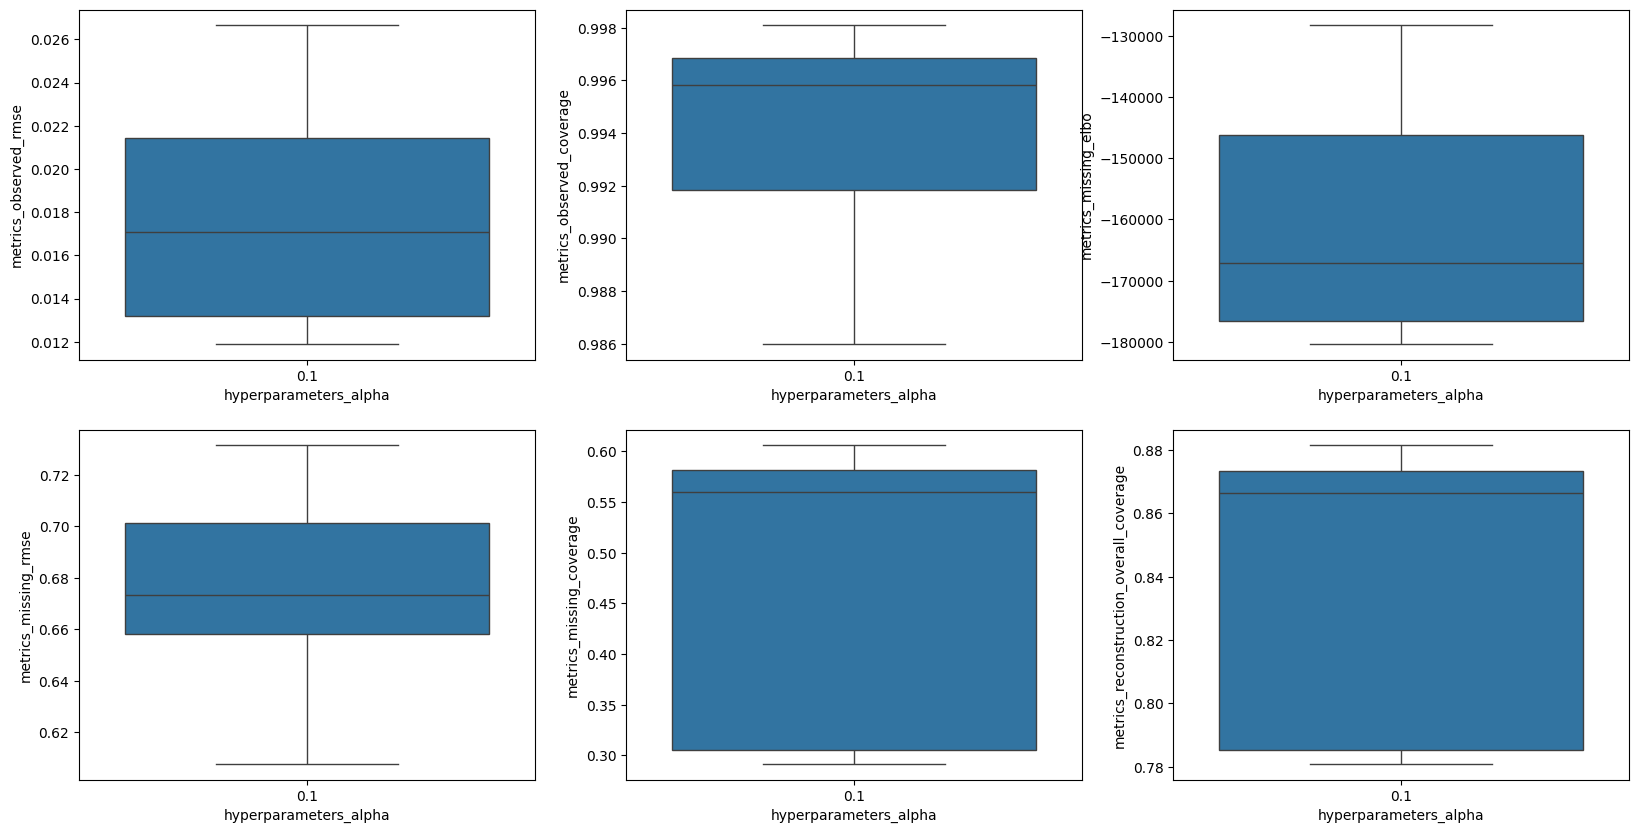

hyperparameters_beta


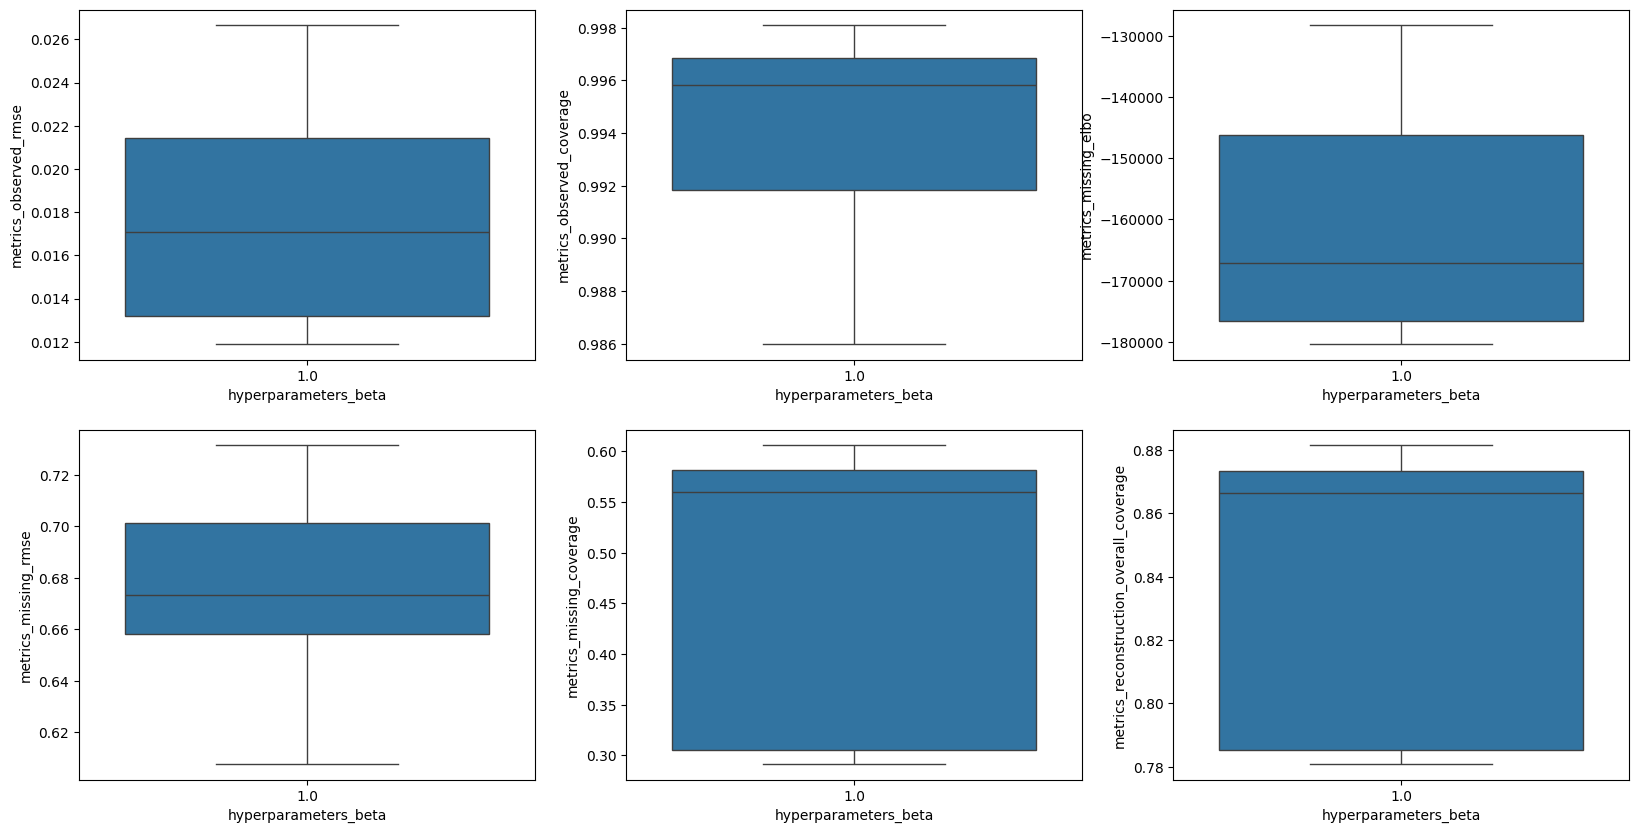

hyperparameters_noise_sigma


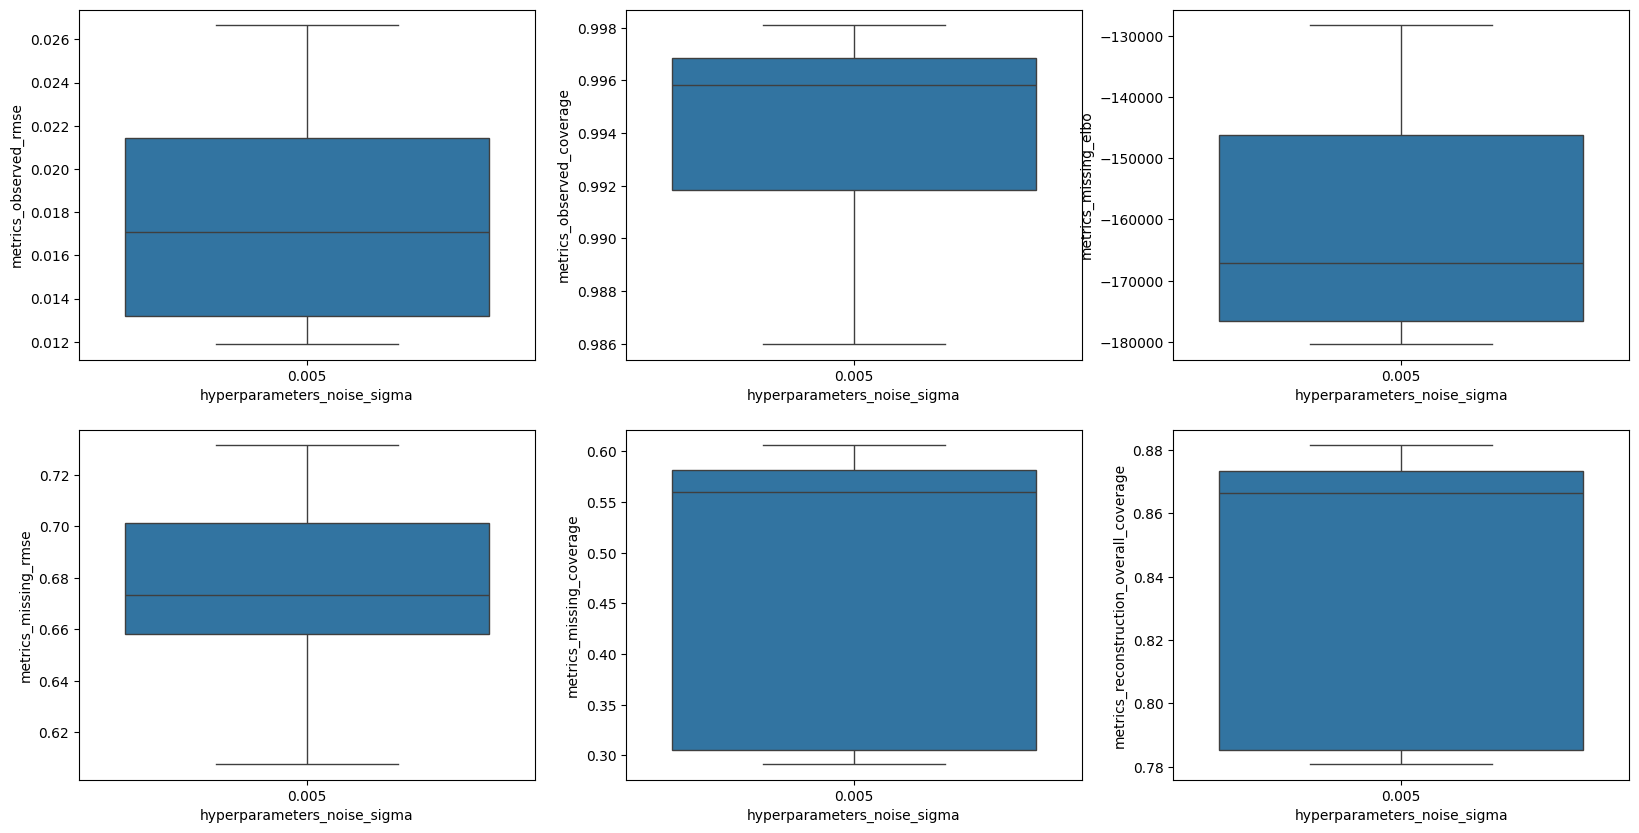

hyperparameters_noise_std


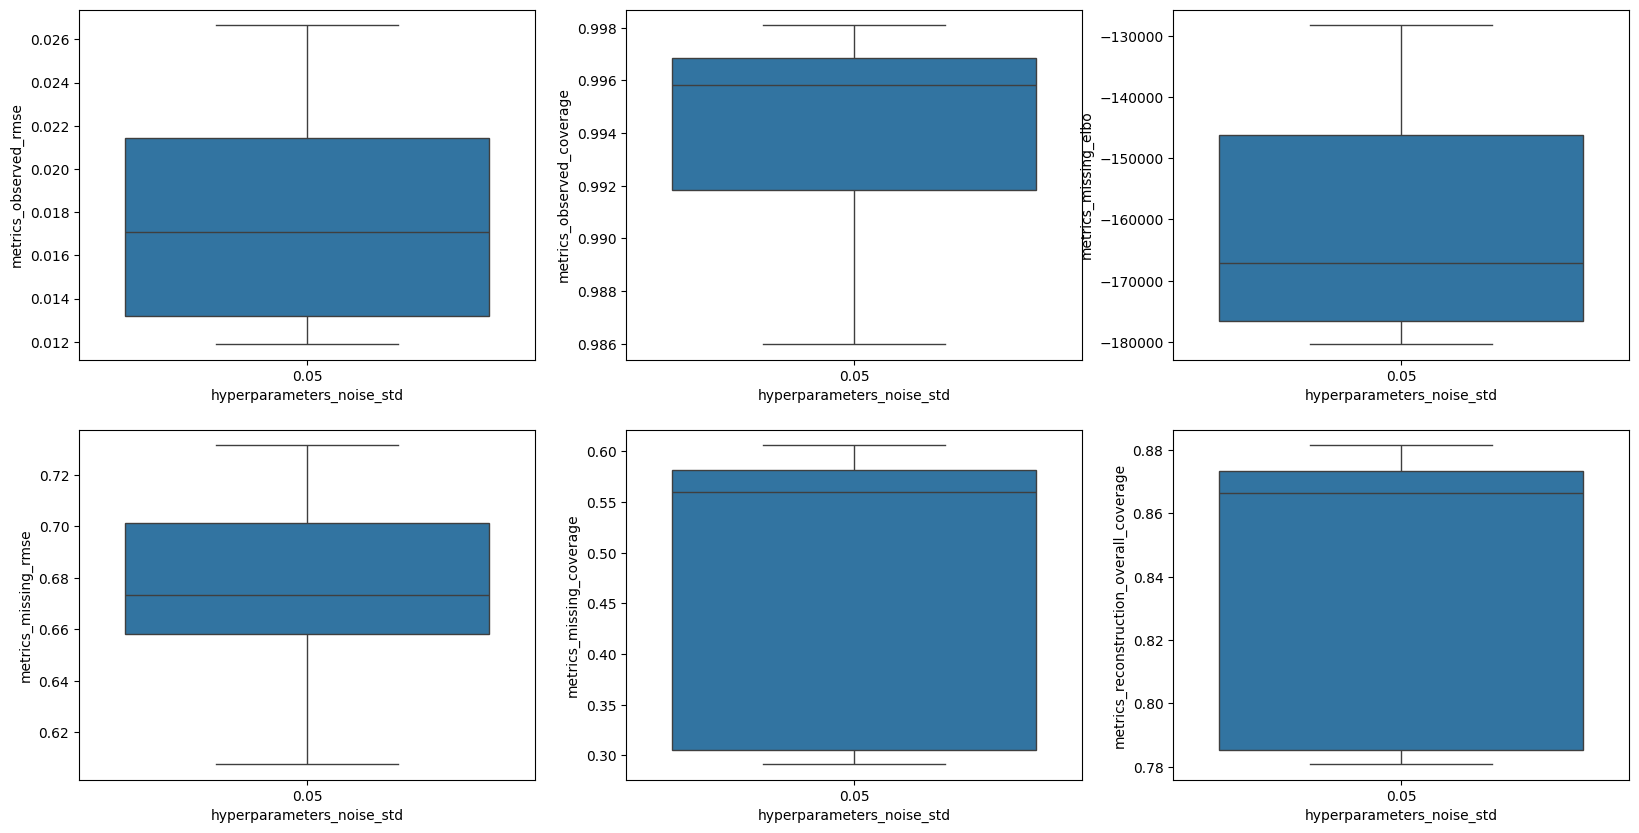

hyperparameters_use_mean_z


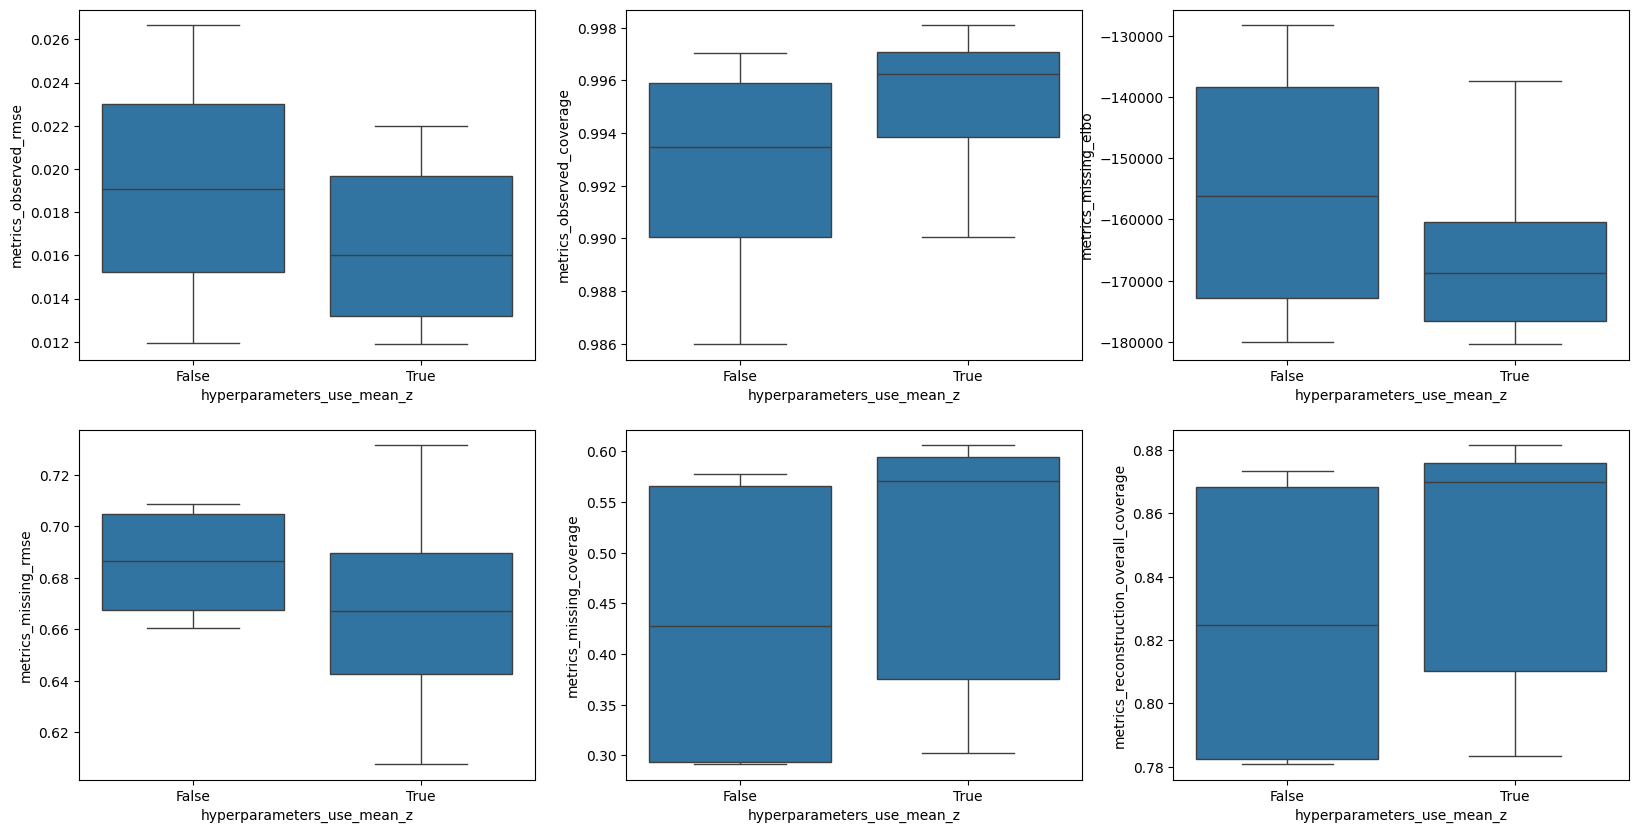

hyperparameters_detach_flag


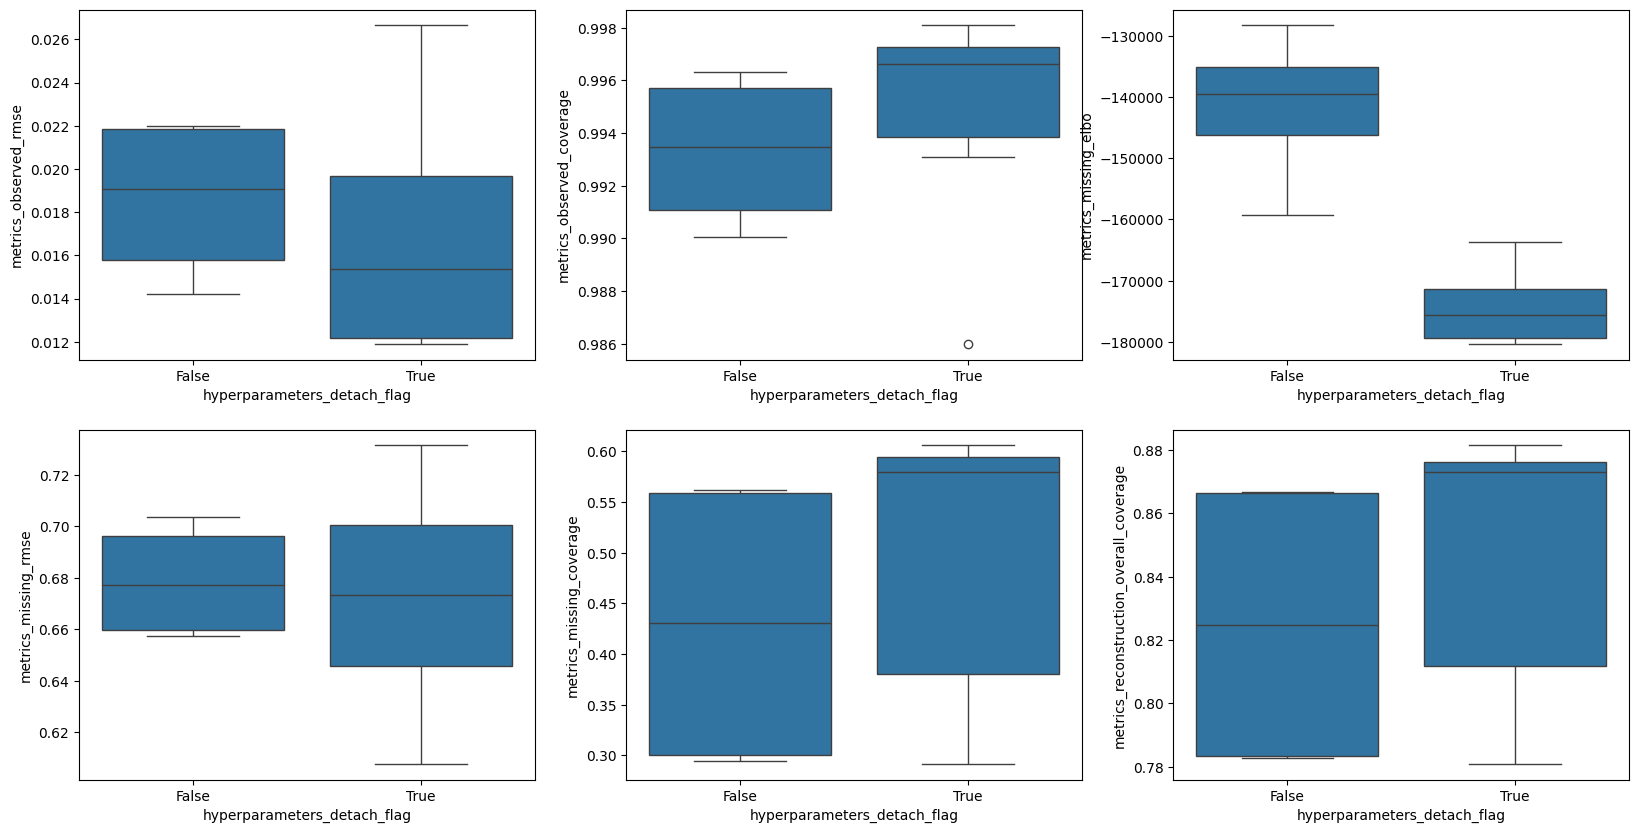

hyperparameters_sampling


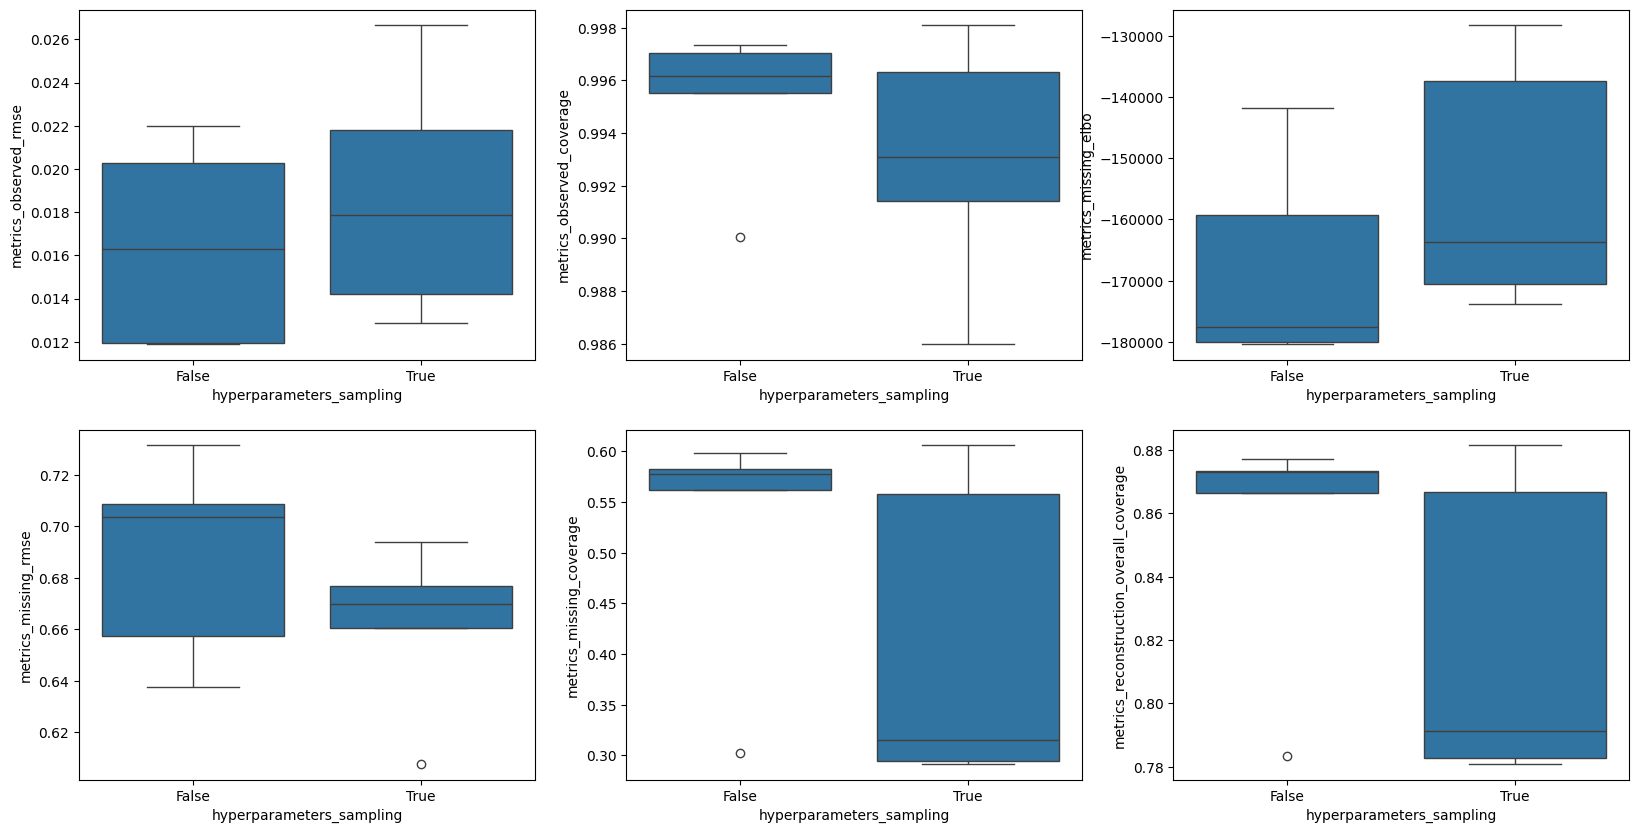

metrics_observed_rmse


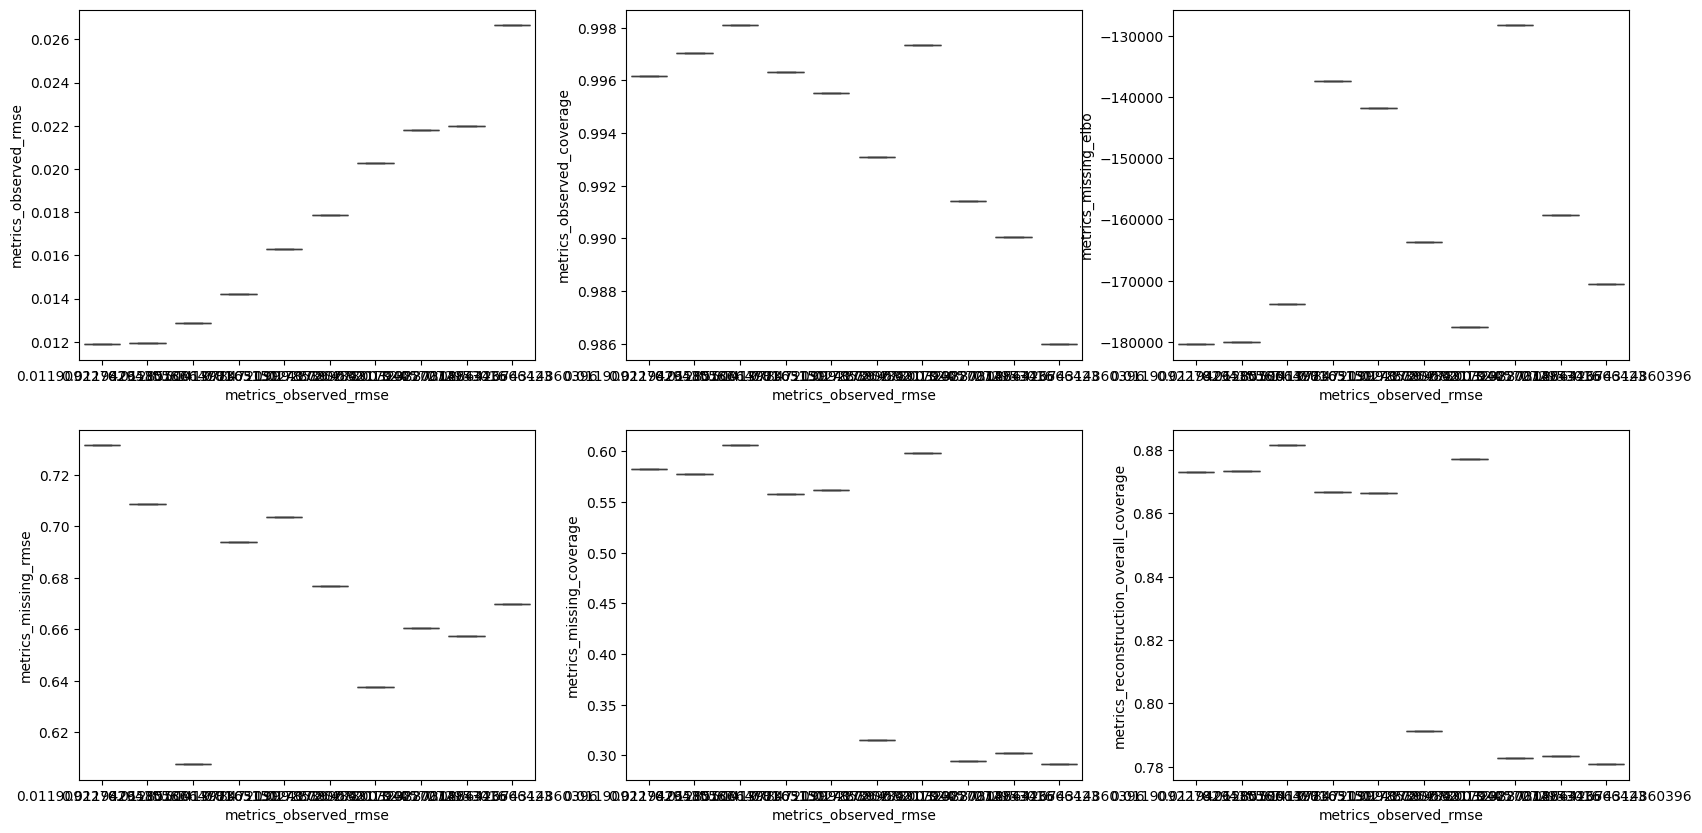

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_missing_elbo',
                     'metrics_missing_rmse','metrics_missing_coverage','metrics_reconstruction_overall_coverage']

hyperparams = df.keys()[1:9].values

for hyperparam in hyperparams:
       print(hyperparam)
       fig, ax = plt.subplots(2,3, figsize=(20,10))
       for i,metric in enumerate(metrics_use_mean_z):
              sns.boxplot(df, y = metric,     
                            x = hyperparam, 
                            ax = ax[i//3, i%3]);
       plt.show();
       #ax[0, 0].set_yscale('log')
       #ax[1, 0].set_yscale('log')

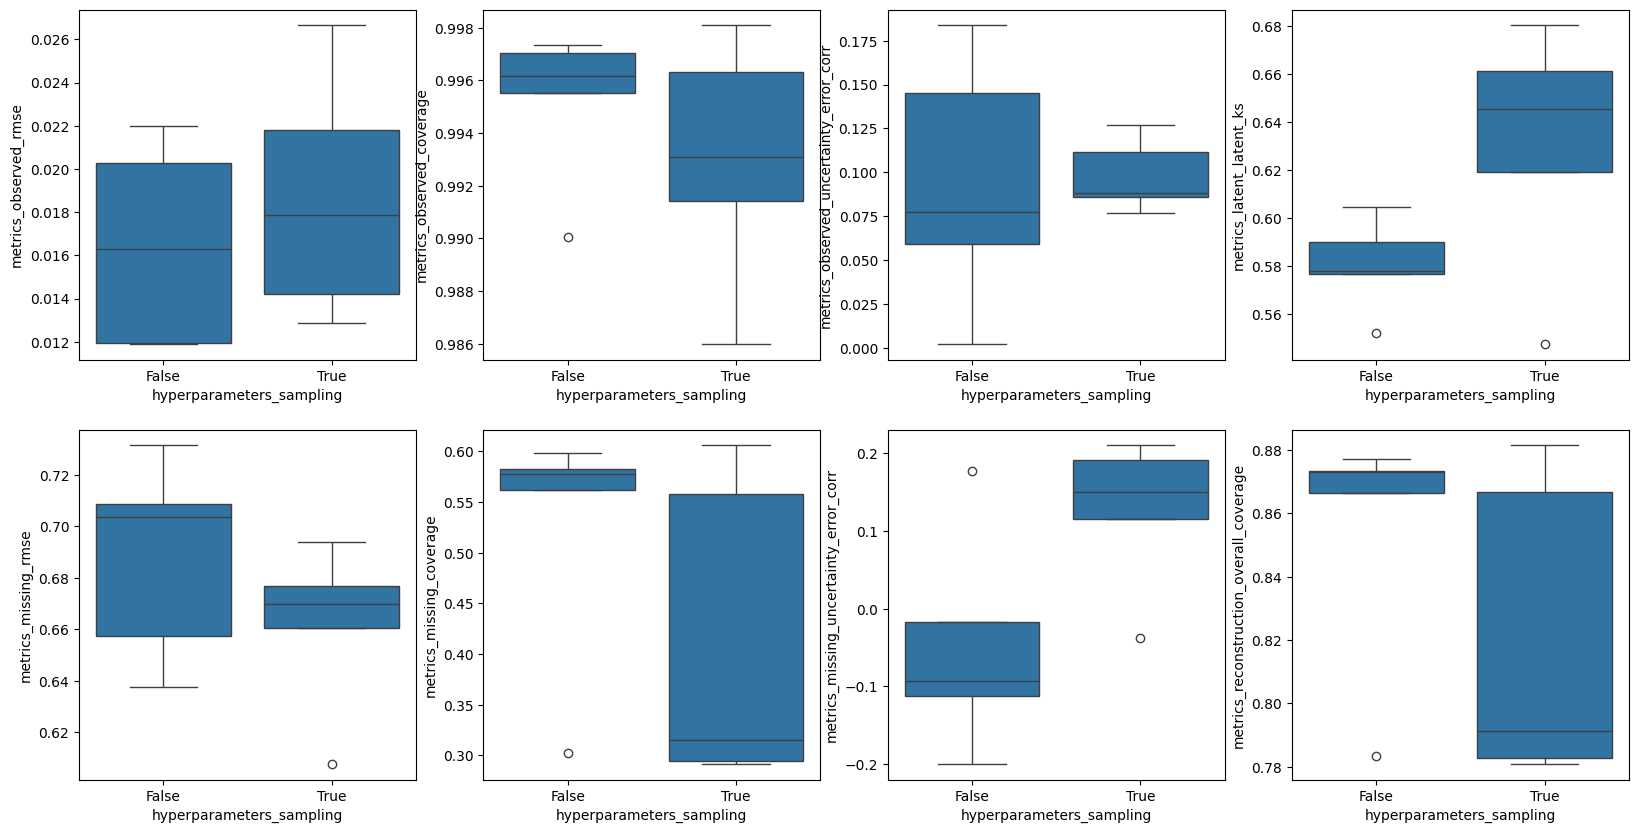

In [17]:
p = 0.5

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr','metrics_latent_latent_ks', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df, y = metric, x = 'hyperparameters_sampling', ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

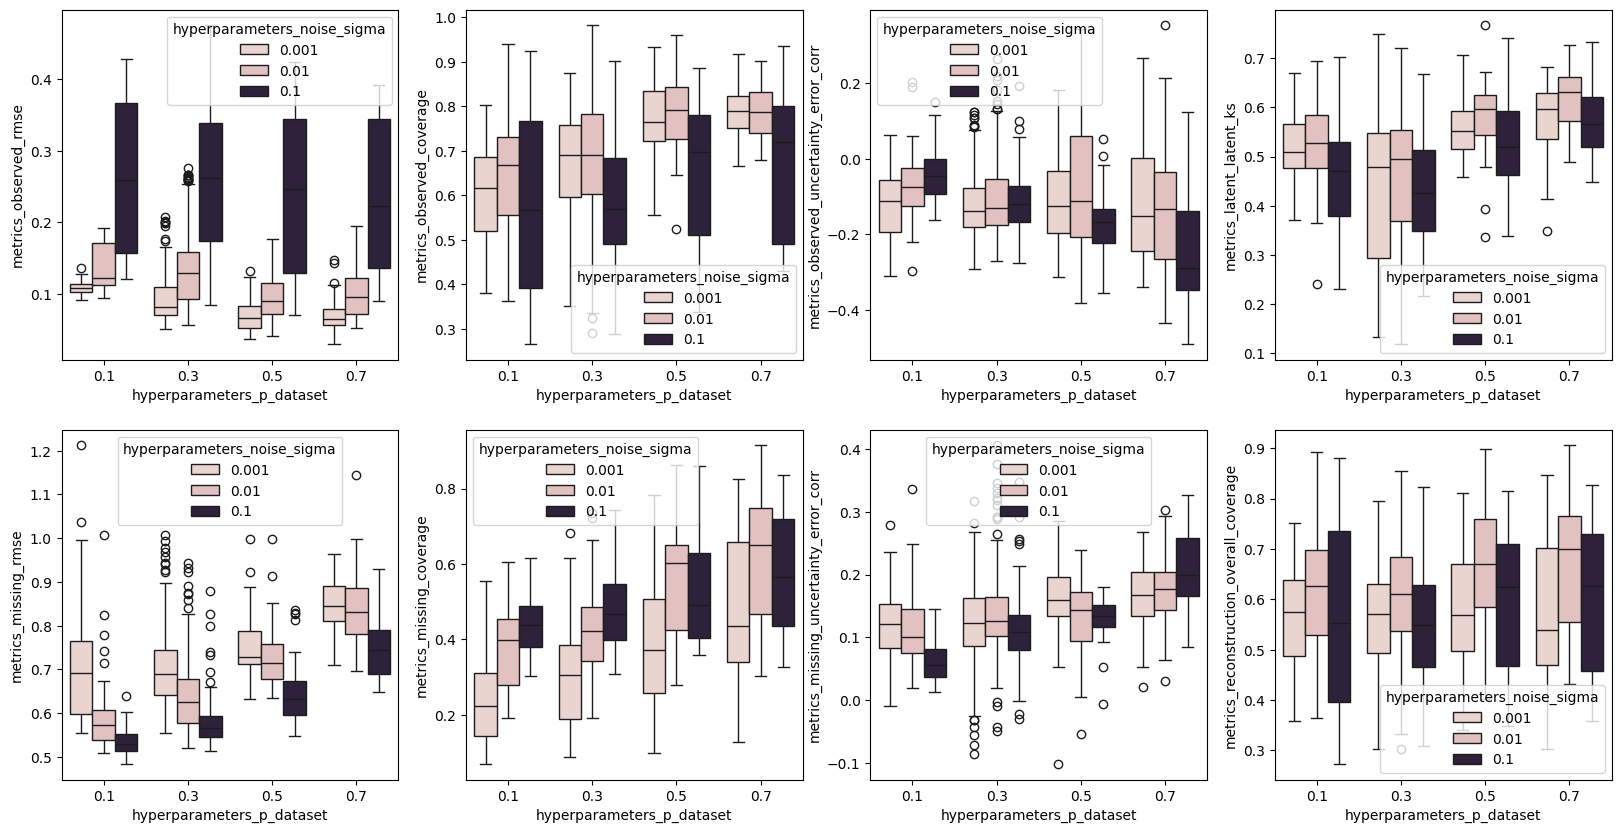

In [347]:
metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr','metrics_latent_latent_ks', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df, y = metric, 
                x = 'hyperparameters_p_dataset', 
                hue = "hyperparameters_noise_sigma", 
                ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

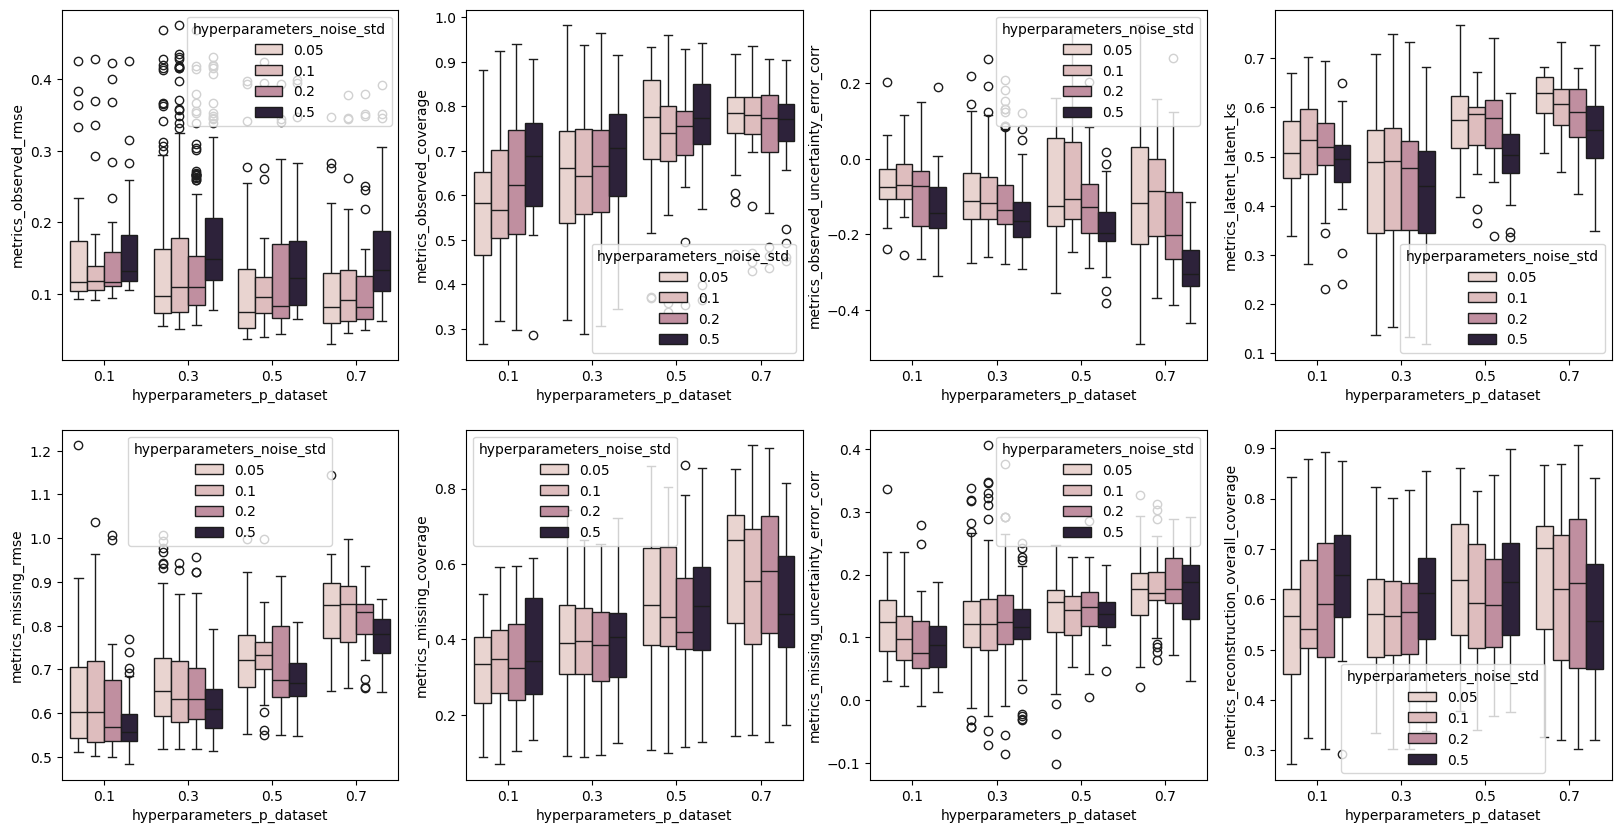

In [348]:
metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr','metrics_latent_latent_ks', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df, y = metric, 
                x = 'hyperparameters_p_dataset', 
                hue = "hyperparameters_noise_std", 
                ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

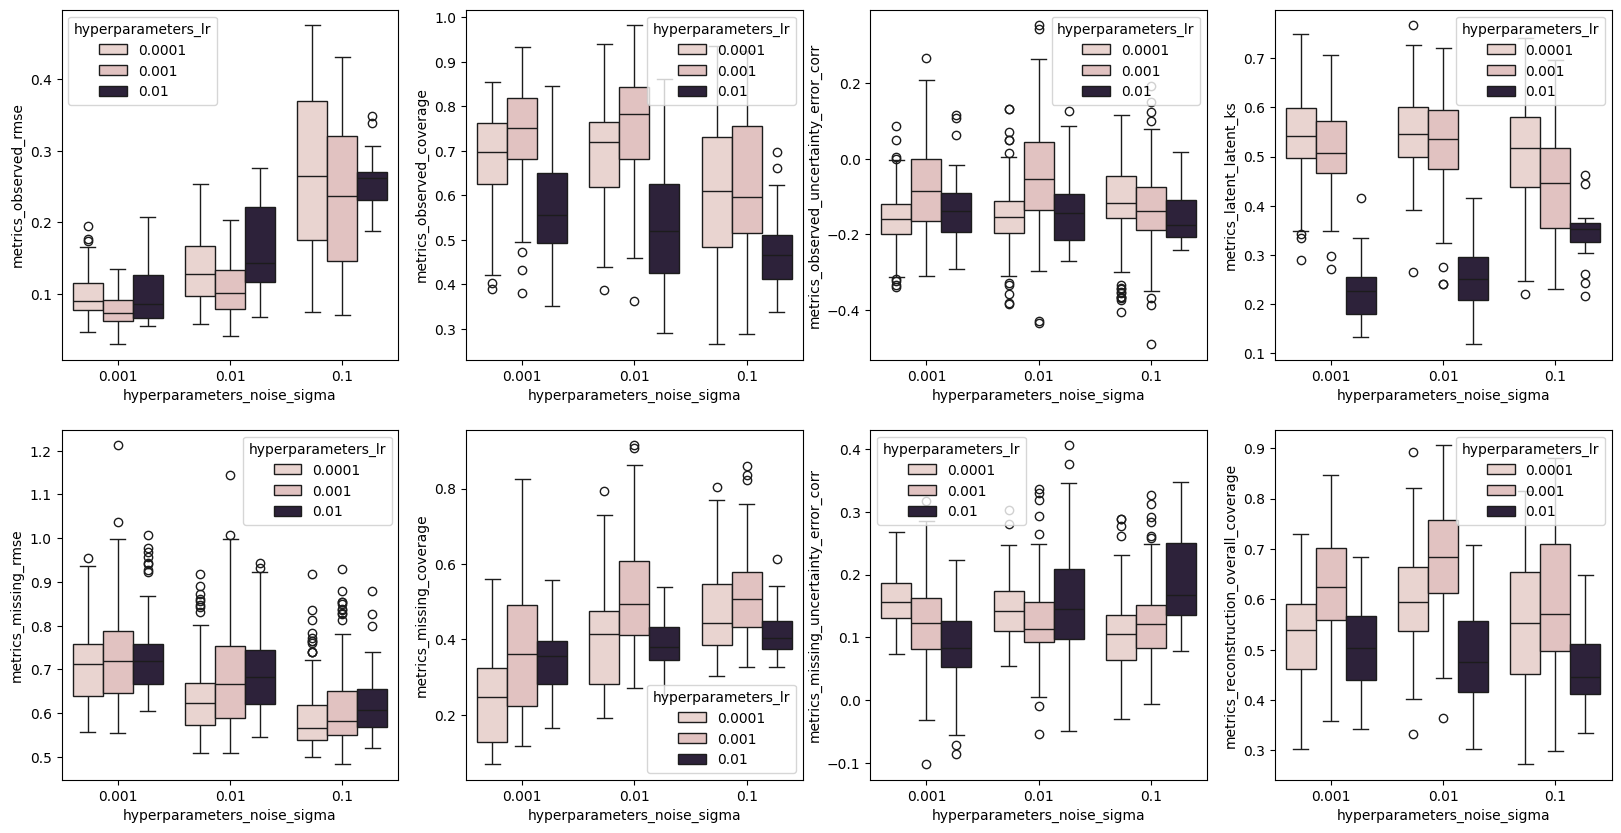

In [349]:
metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr','metrics_latent_latent_ks', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df, y = metric, x = 'hyperparameters_noise_sigma', hue = 'hyperparameters_lr', ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

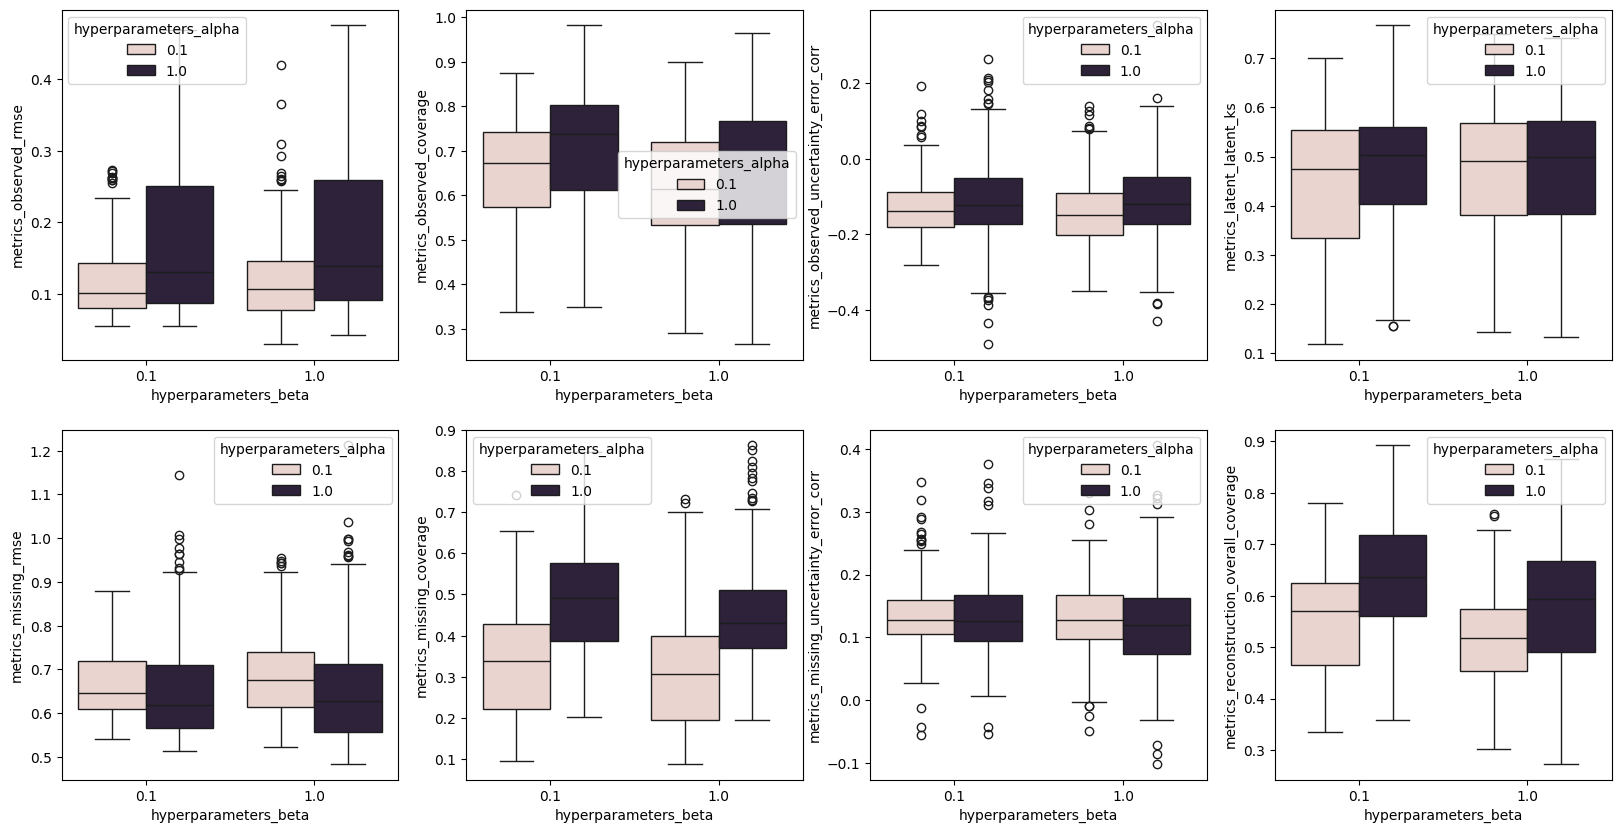

In [330]:
metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr','metrics_latent_latent_ks', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df, y = metric, x = 'hyperparameters_beta', hue = 'hyperparameters_alpha', ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

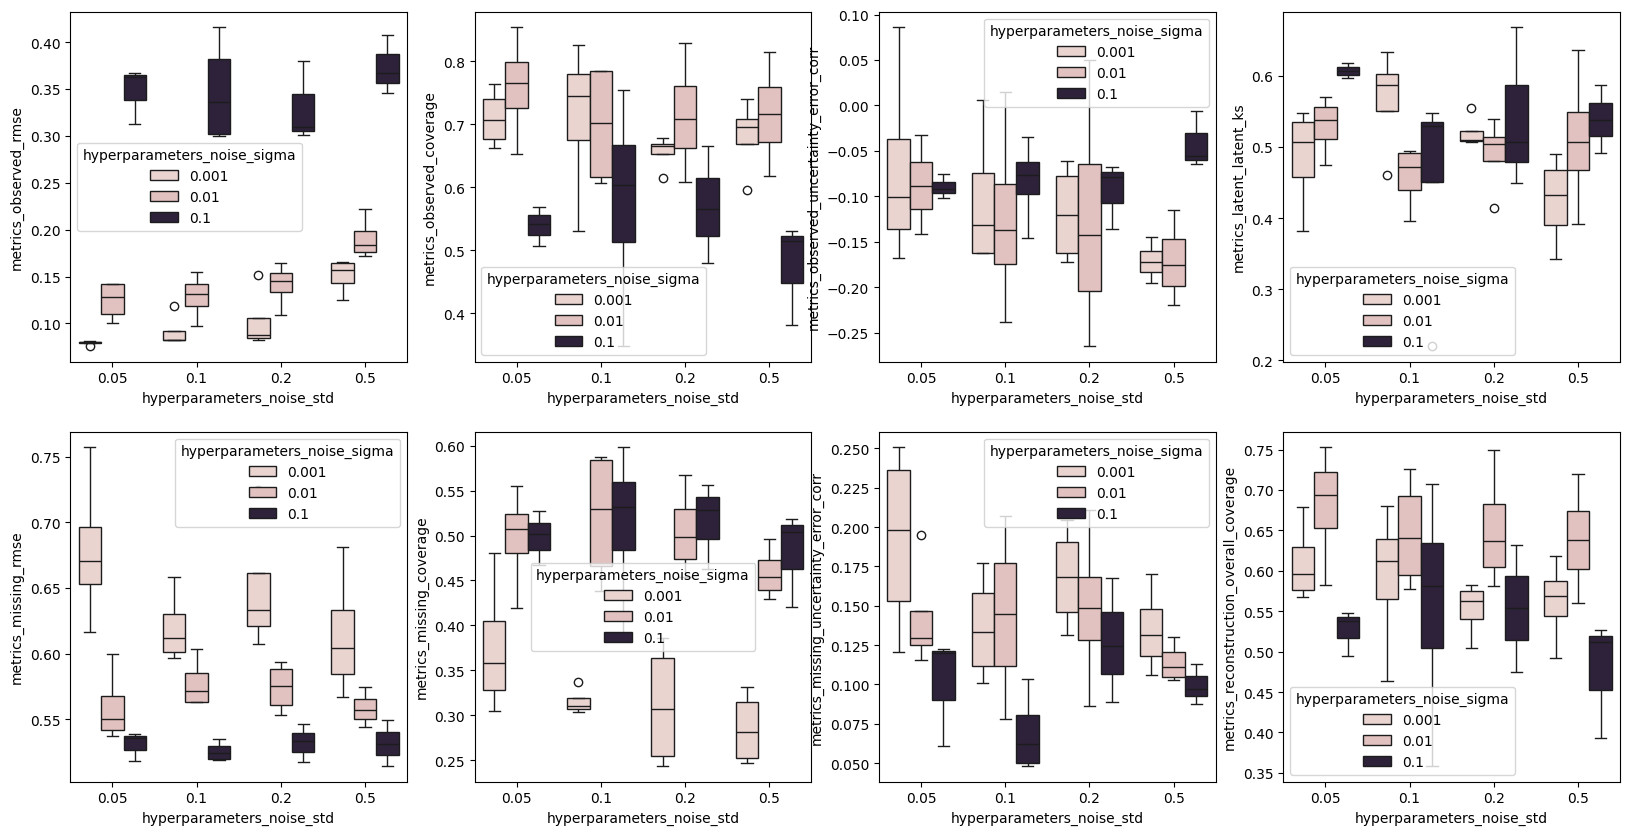

In [331]:
metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr','metrics_latent_latent_ks', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df_restricted, y = metric, x = 'hyperparameters_noise_std', hue = 'hyperparameters_noise_sigma', ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

In [332]:
mask = (df.hyperparameters_lr<0.01) & (df.hyperparameters_alpha == 1.)
df_restricted = df[mask]

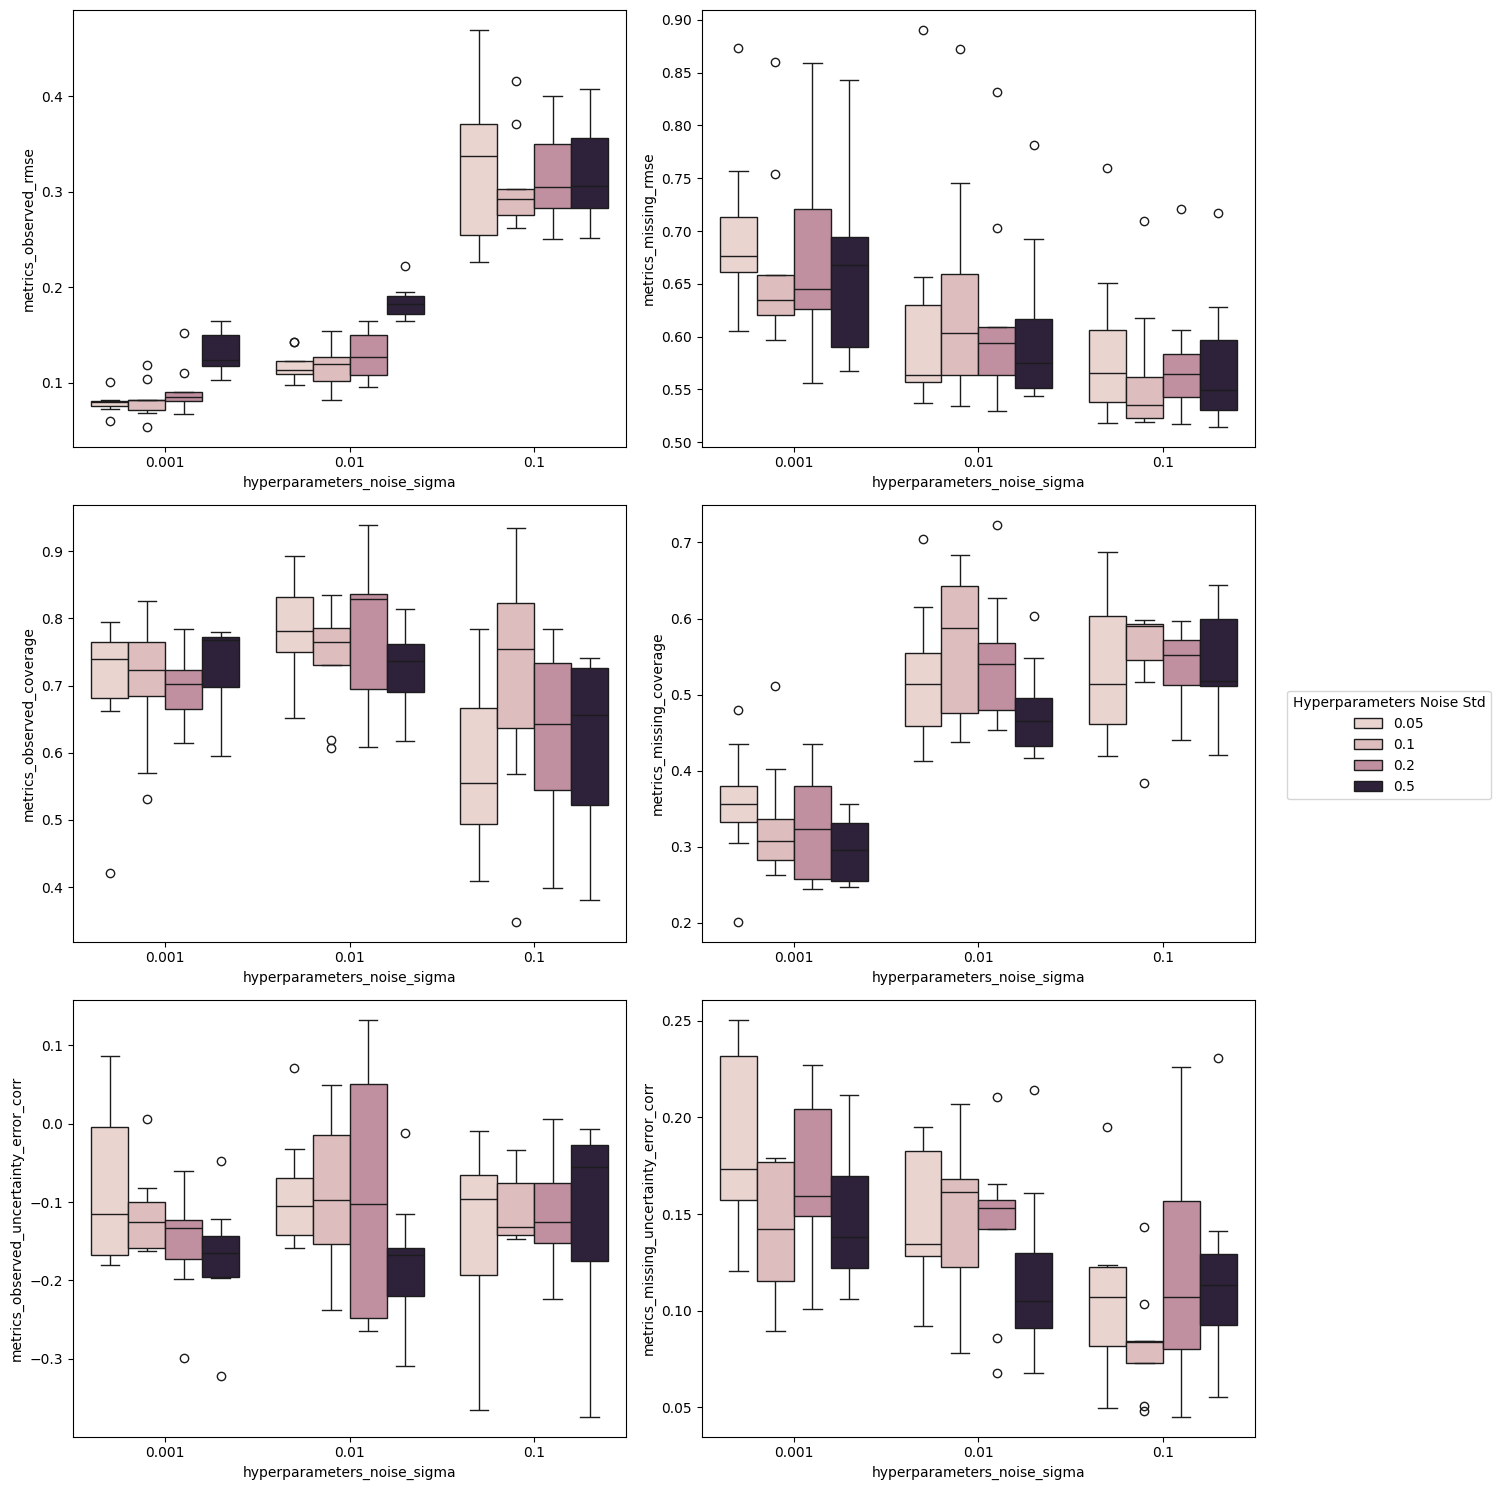

In [333]:
mask = (df.hyperparameters_lr<0.01) & (df.hyperparameters_alpha == 1.) & (df.hyperparameters_beta == 0.1) & (df.hyperparameters_lr == 0.0001)
df_restricted = df[mask]

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr', 
       'metrics_missing_rmse', 'metrics_missing_coverage', 'metrics_missing_uncertainty_error_corr']

fig, ax = plt.subplots(3, 2, figsize=(15, 15))
handles, labels = None, None

for i, metric in enumerate(metrics_use_mean_z):
    boxplot = sns.boxplot(
        data=df_restricted, 
        y=metric, 
        x='hyperparameters_noise_sigma', 
        hue='hyperparameters_noise_std', 
        ax=ax[i % 3, i // 3]
    )
    
    if handles is None or labels is None:
        handles, labels = boxplot.get_legend_handles_labels()
    ax[i % 3, i // 3].legend_.remove()  # Remove individual legends

# Add a single legend on the side
fig.legend(handles, labels, loc='center right', title='Hyperparameters Noise Std')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to fit legend
plt.show()

In [350]:
df_restricted = df[df.metrics_observed_rmse < 0.1]

<Axes: xlabel='metrics_observed_coverage', ylabel='metrics_missing_coverage'>

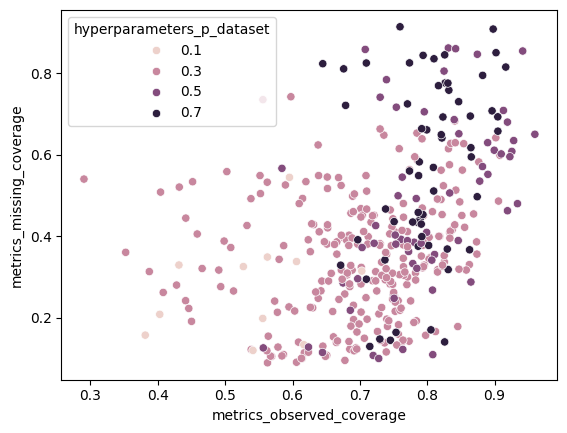

In [351]:
import seaborn as sns

sns.scatterplot(df_restricted, x = 'metrics_observed_coverage', y = 'metrics_missing_coverage', hue = 'hyperparameters_p_dataset')

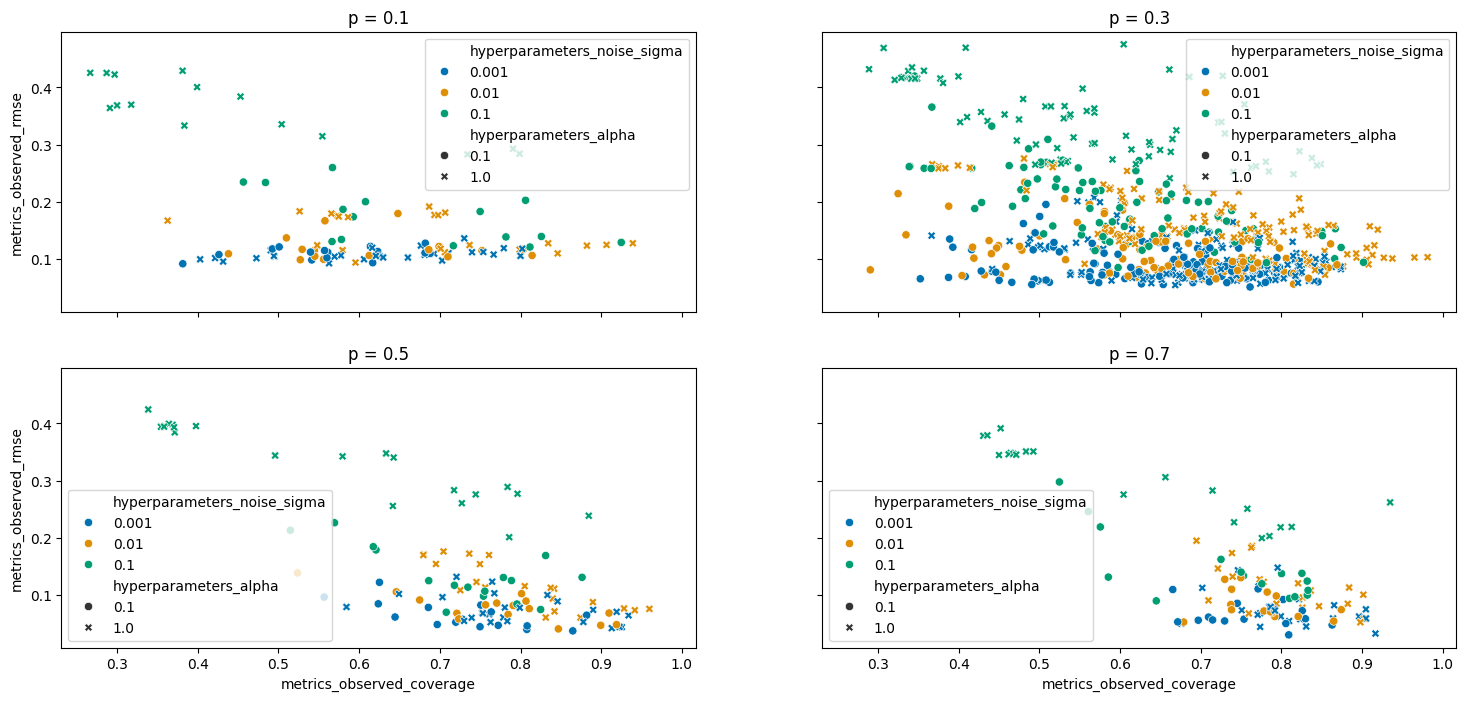

In [355]:
fig, ax = plt.subplots(2,2, figsize = (18,8), sharex = True, sharey = True)
cmap = "colorblind"  # Alternative: "cividis", "plasma", "magma"
for i,p in enumerate([0.1, 0.3, 0.5, 0.7]):
    mask = (df.hyperparameters_p_dataset == p) #& (df.hyperparameters_beta == .1) & (df.hyperparameters_lr == 0.001)
    sns.scatterplot(df[mask], 
                    x = 'metrics_observed_coverage', 
                    y = 'metrics_observed_rmse', 
                    hue = 'hyperparameters_noise_sigma',
                    style = 'hyperparameters_alpha',
                    ax = ax[i//2,i%2],
                    palette = cmap)
    ax[i//2,i%2].set_title(f'p = {p}')

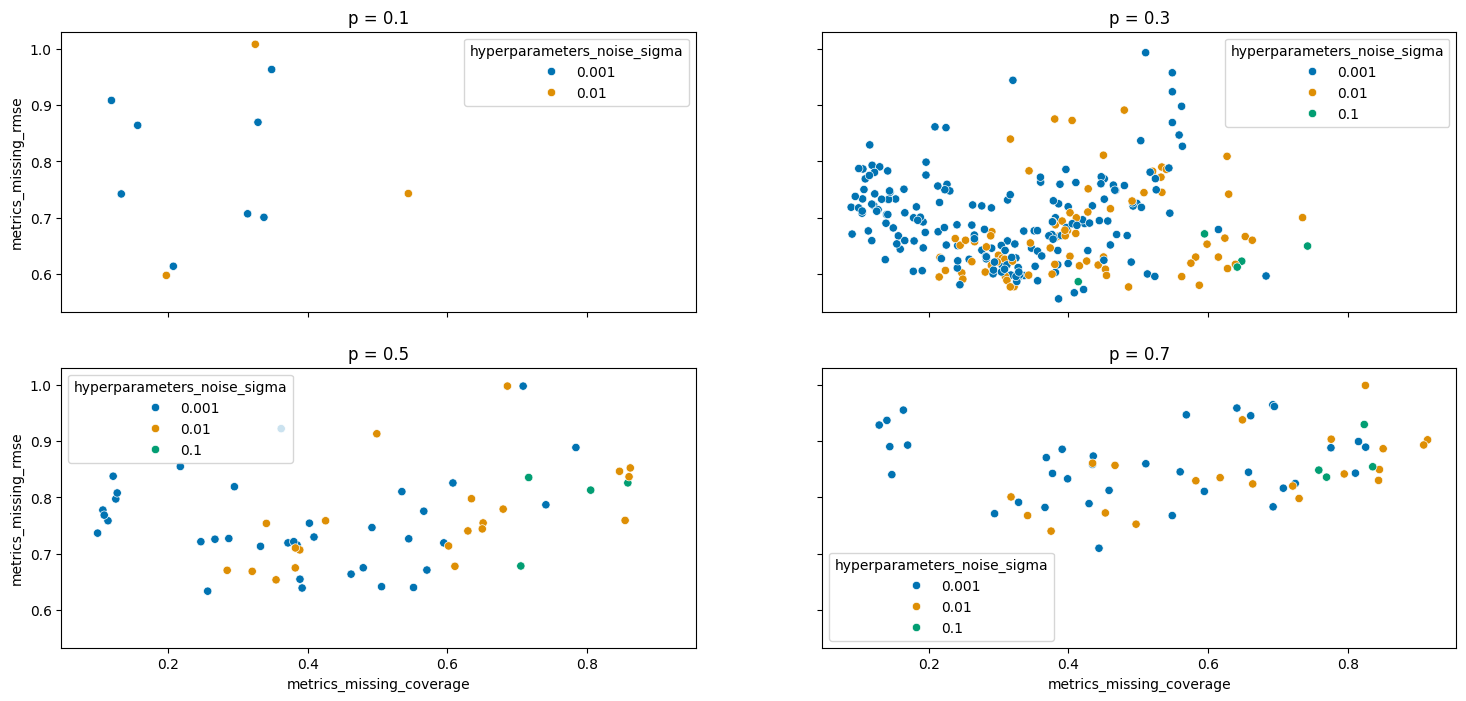

In [356]:
fig, ax = plt.subplots(2,2, figsize = (18,8), sharex = True, sharey = True)
cmap = "colorblind"  # Alternative: "cividis", "plasma", "magma"
for i,p in enumerate([0.1, 0.3, 0.5, 0.7]):
    sns.scatterplot(df_restricted[df_restricted.hyperparameters_p_dataset==p], 
                    x = 'metrics_missing_coverage', 
                    y = 'metrics_missing_rmse', 
                    hue = 'hyperparameters_noise_sigma', 
                    ax = ax[i//2,i%2],
                    palette = cmap)
    ax[i//2,i%2].set_title(f'p = {p}')

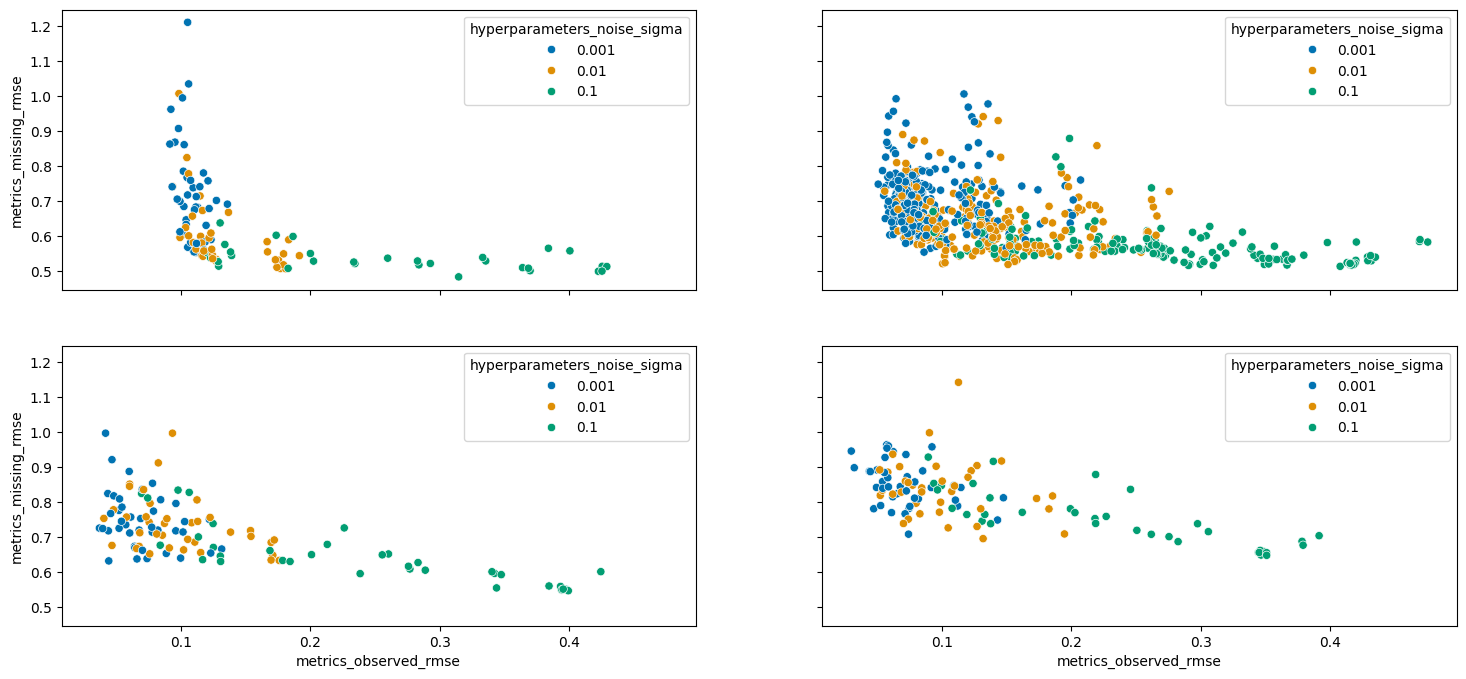

In [359]:
fig, ax = plt.subplots(2,2, figsize = (18,8), sharex = True, sharey = True)
for i,p in enumerate([0.1, 0.3, 0.5, 0.7]):
    sns.scatterplot(df[df.hyperparameters_p_dataset==p], 
                    x = 'metrics_observed_rmse', 
                    y = 'metrics_missing_rmse', 
                    hue = 'hyperparameters_noise_sigma', 
                    palette = cmap,
                    ax = ax[i//2,i%2])

<Axes: xlabel='metrics_observed_rmse', ylabel='metrics_missing_rmse'>

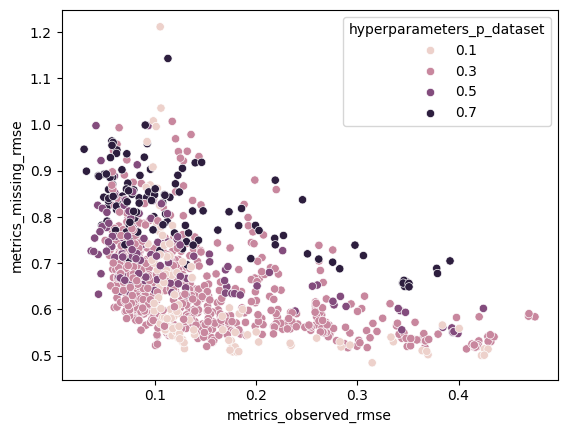

In [361]:
import seaborn as sns

#for p in [0.1, ]
sns.scatterplot(df, x = 'metrics_observed_rmse', y = 'metrics_missing_rmse', hue = 'hyperparameters_p_dataset')

<Axes: xlabel='metrics_observed_coverage', ylabel='metrics_missing_coverage'>

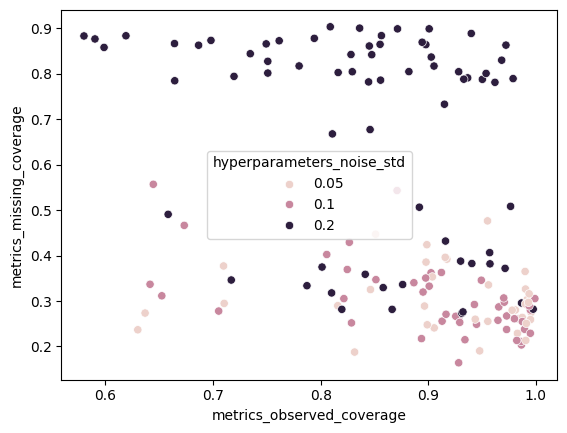

In [101]:
import seaborn as sns

sns.scatterplot(df, x = 'metrics_observed_coverage', y = 'metrics_missing_coverage', hue = 'hyperparameters_noise_std')

<Axes: xlabel='metrics_observed_coverage', ylabel='metrics_observed_uncertainty_error_corr'>

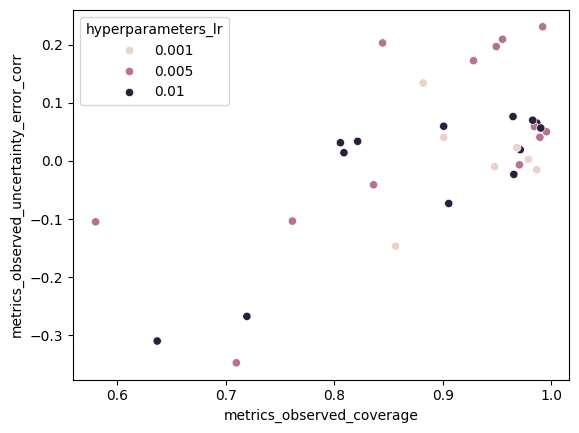

In [31]:
sns.scatterplot(df, x = 'metrics_observed_coverage', y = 'metrics_observed_uncertainty_error_corr', hue = 'hyperparameters_lr')

Text(0.5, 1.0, 'Missing coverage vs Missing RMSE')

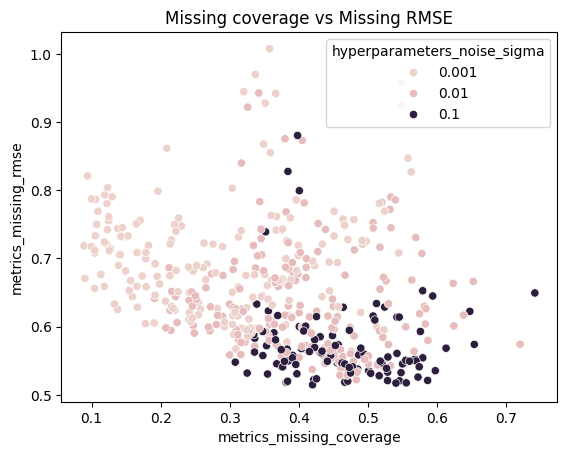

In [170]:
sns.scatterplot(df, x = 'metrics_missing_coverage', y = 'metrics_missing_rmse', hue = 'hyperparameters_noise_sigma')
plt.title('Missing coverage vs Missing RMSE')

Text(0.5, 1.0, 'Missing coverage vs Missing RMSE')

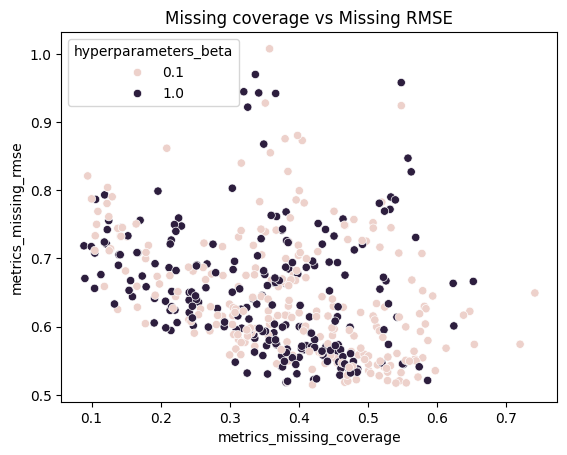

In [173]:
sns.scatterplot(df, x = 'metrics_missing_coverage', y = 'metrics_missing_rmse', hue = 'hyperparameters_beta')
plt.title('Missing coverage vs Missing RMSE')

Text(0.5, 1.0, 'Missing coverage vs Missing RMSE')

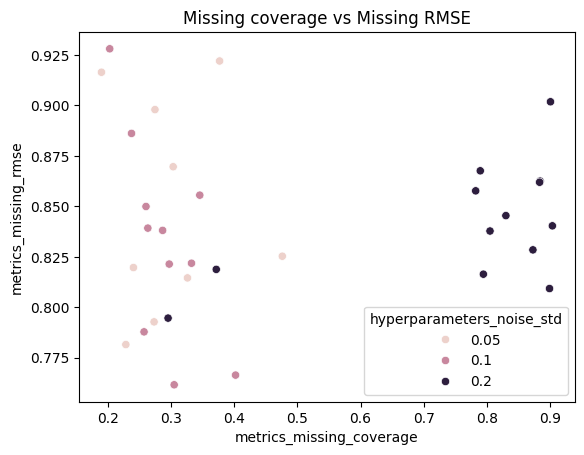

In [36]:
sns.scatterplot(df, x = 'metrics_missing_coverage', y = 'metrics_missing_rmse', hue = 'hyperparameters_noise_std')
plt.title('Missing coverage vs Missing RMSE')

<Axes: xlabel='metrics_observed_rmse', ylabel='metrics_missing_rmse'>

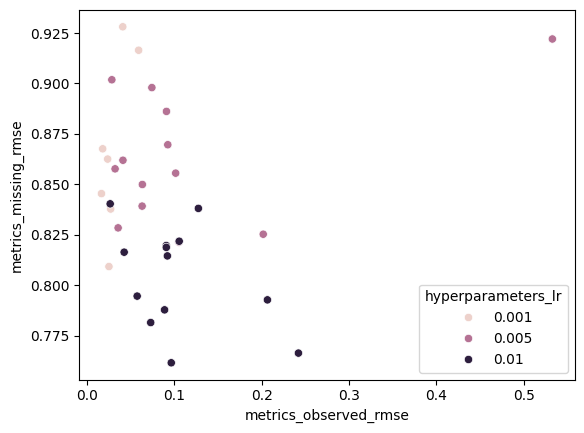

In [29]:
sns.scatterplot(df, x = 'metrics_observed_rmse', y = 'metrics_missing_rmse', hue = 'hyperparameters_lr')

<Axes: xlabel='metrics_observed_rmse', ylabel='metrics_missing_rmse'>

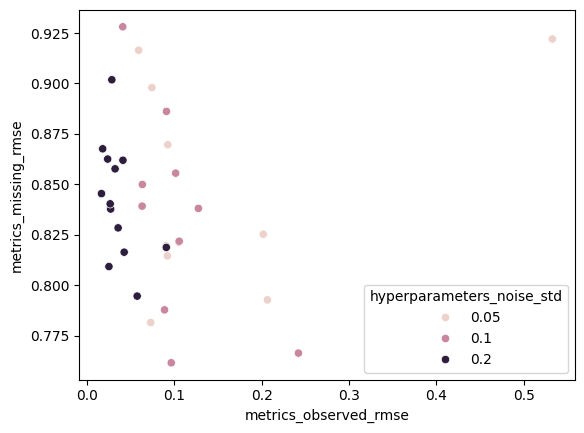

In [30]:
sns.scatterplot(df, x = 'metrics_observed_rmse', y = 'metrics_missing_rmse', hue = 'hyperparameters_noise_std')

<Axes: xlabel='metrics_observed_rmse', ylabel='metrics_missing_rmse'>

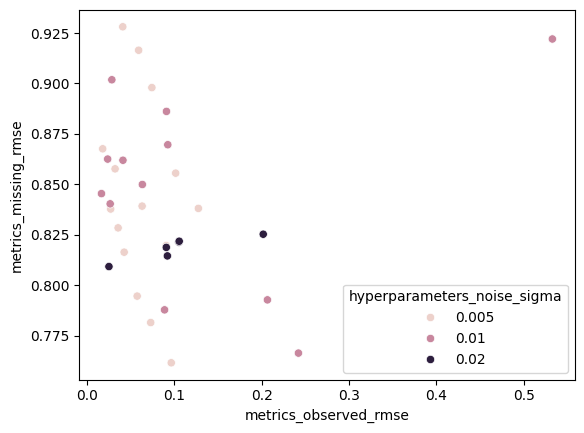

In [23]:
sns.scatterplot(df, x = 'metrics_observed_rmse', y = 'metrics_missing_rmse', hue = 'hyperparameters_noise_sigma')

<Axes: xlabel='hyperparameters_noise_sigma', ylabel='metrics_missing_rmse'>

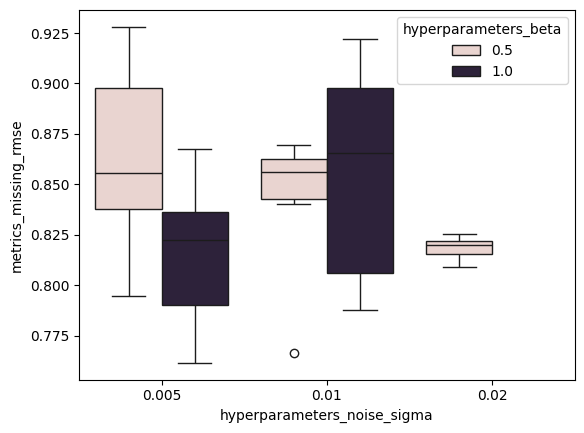

In [24]:
sns.boxplot(df, x = 'hyperparameters_noise_sigma', y = 'metrics_missing_rmse', hue = 'hyperparameters_beta')

<Axes: xlabel='metrics_observed_rmse', ylabel='metrics_missing_rmse'>

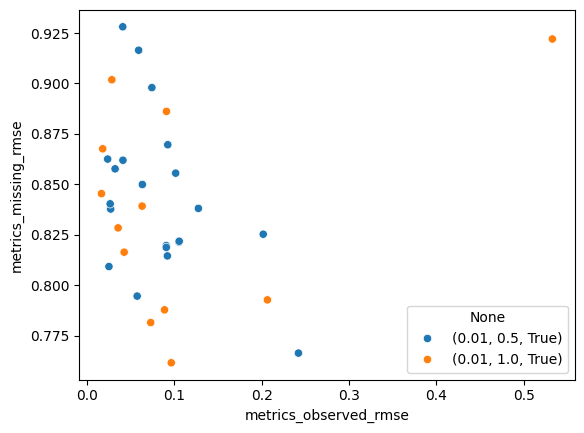

In [25]:
hp1, hp2 = 'hyperparameters_alpha','hyperparameters_beta'
sns.scatterplot(df, x = 'metrics_observed_rmse', y = 'metrics_missing_rmse', 
                hue = df[[hp1, hp2, 'hyperparameters_use_mean_z']].apply(tuple, axis=1))

<Axes: xlabel='metrics_observed_rmse', ylabel='metrics_missing_rmse'>

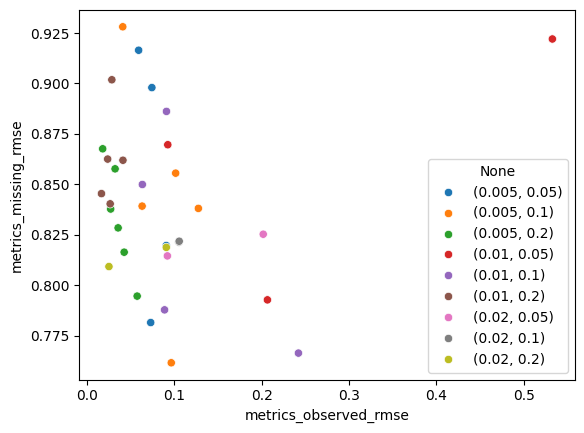

In [26]:
sns.scatterplot(df, x = 'metrics_observed_rmse', y = 'metrics_missing_rmse', hue = df[['hyperparameters_noise_sigma','hyperparameters_noise_std']].apply(tuple, axis=1))

<Axes: xlabel='hyperparameters_noise_sigma', ylabel='metrics_observed_rmse'>

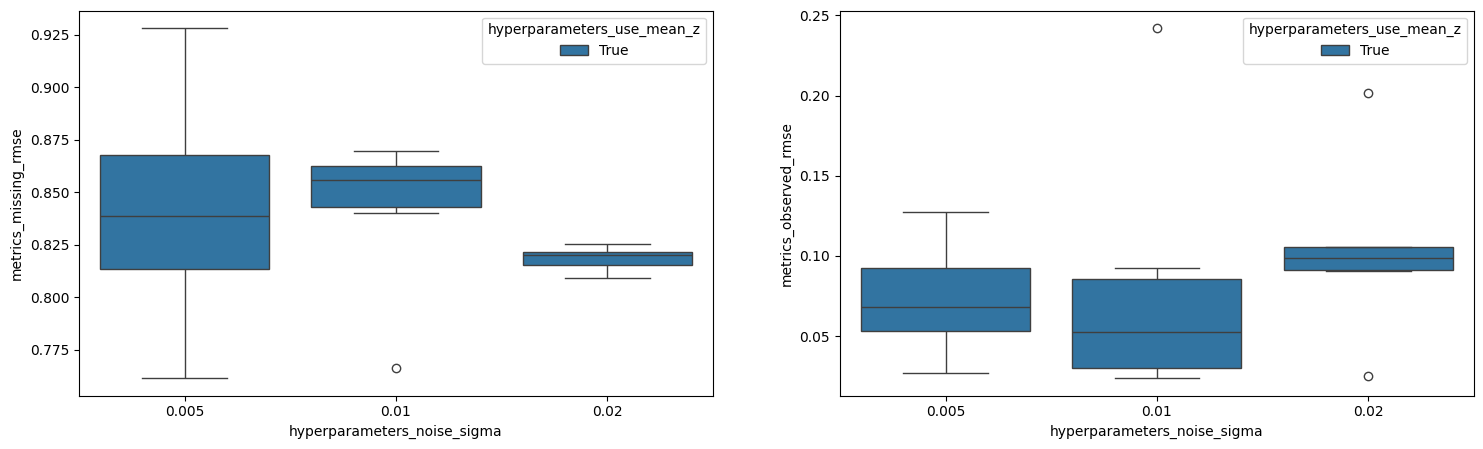

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

x = 'hyperparameters_noise_sigma'
y = 'rmse'

y_0 = f'metrics_missing_{y}'
y_1 = f'metrics_observed_{y}'
hue = 'hyperparameters_noise_std'
hue = 'hyperparameters_use_mean_z'

fig, ax = plt.subplots(1, 2, figsize=(18,5))
sns.boxplot(df, x = x, y = y_0, hue = hue, ax = ax[0])
sns.boxplot(df, x = x, y = y_1, hue = hue, ax = ax[1])

<Axes: xlabel='hyperparameters_noise_std', ylabel='metrics_observed_rmse'>

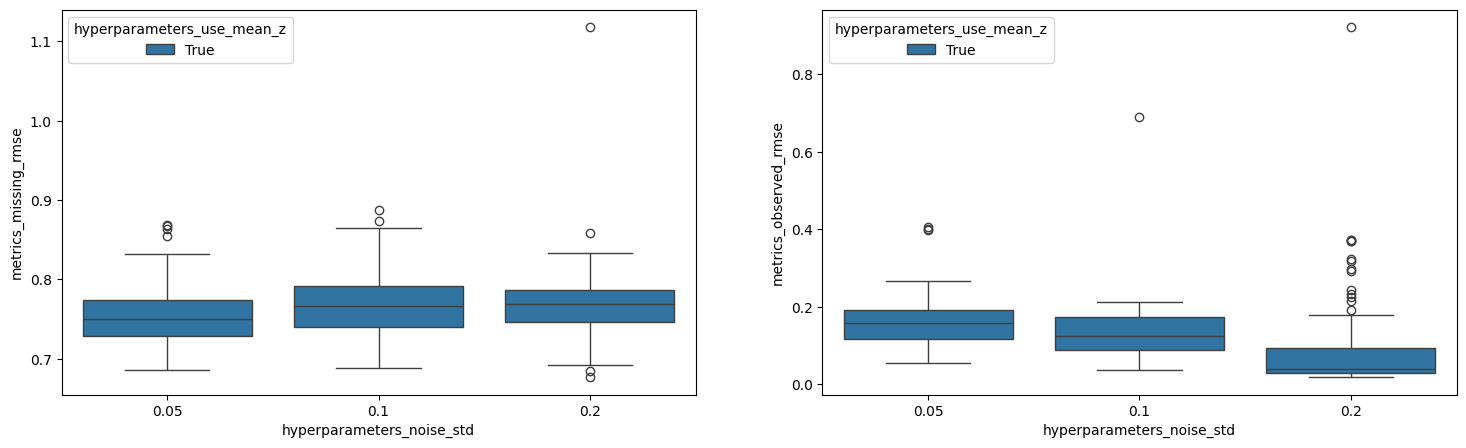

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

x = 'hyperparameters_noise_std'
y = 'rmse'

y_0 = f'metrics_missing_{y}'
y_1 = f'metrics_observed_{y}'
hue = 'hyperparameters_noise_std'
hue = 'hyperparameters_use_mean_z'
#hue = None

fig, ax = plt.subplots(1, 2, figsize=(18,5))
sns.boxplot(df, x = x, y = y_0, hue = hue, ax = ax[0])
sns.boxplot(df, x = x, y = y_1, hue = hue, ax = ax[1])

<Axes: xlabel='hyperparameters_beta', ylabel='metrics_observed_rmse'>

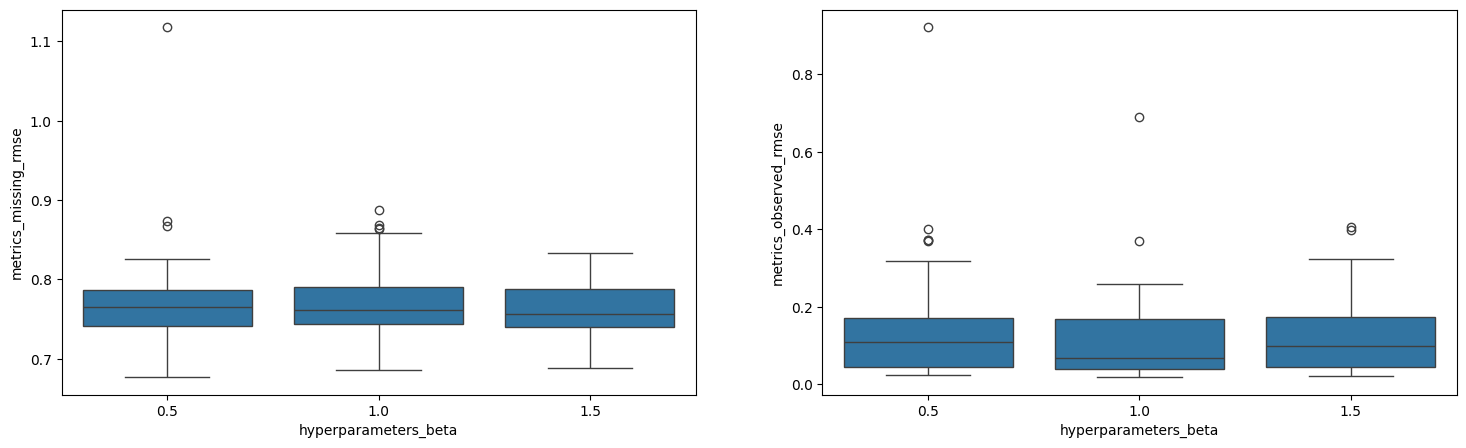

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

x = 'hyperparameters_beta'
y = 'rmse'

y_0 = f'metrics_missing_{y}'
y_1 = f'metrics_observed_{y}'
hue = 'hyperparameters_beta'
#hue = 'hyperparameters_use_mean_z'
hue = None

fig, ax = plt.subplots(1, 2, figsize=(18,5))
sns.boxplot(df, x = x, y = y_0, hue = hue, ax = ax[0])
sns.boxplot(df, x = x, y = y_1, hue = hue, ax = ax[1])

<Axes: xlabel='hyperparameters_noise_sigma', ylabel='metrics_missing_rmse'>

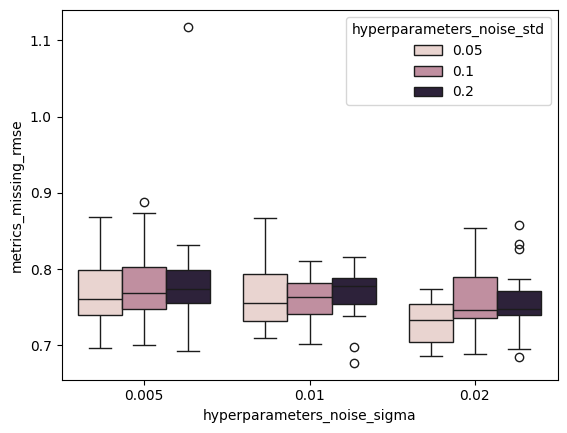

In [ ]:
sns.boxplot(df, x = 'hyperparameters_noise_sigma', y = 'metrics_missing_rmse', hue = 'hyperparameters_noise_std')

In [ ]:
df['Converged'] = (df.metrics_observed_rmse!=df.metrics_observed_rmse)

<Axes: xlabel='Converged', ylabel='hyperparameters_beta'>

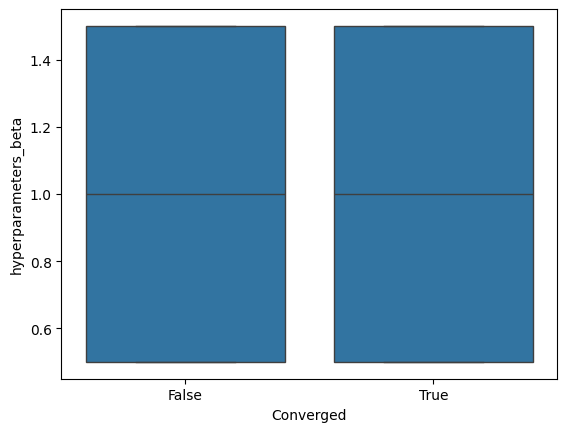

In [ ]:
sns.boxplot(df, x = 'Converged', y = 'hyperparameters_beta')

In [ ]:
df[df.Converged]

,training_time,hyperparameters_alpha,hyperparameters_beta,hyperparameters_noise_sigma,hyperparameters_noise_std,hyperparameters_use_mean_z,hyperparameters_detach_flag,metrics_observed_rmse,metrics_observed_nll,metrics_observed_elbo,metrics_observed_coverage,metrics_observed_uncertainty_error_corr,metrics_missing_rmse,metrics_missing_nll,metrics_missing_elbo,metrics_missing_coverage,metrics_missing_uncertainty_error_corr,metrics_latent_latent_ks,metrics_reconstruction_overall_coverage,Converged
0,19.485421,0.01,0.5,0.005,0.05,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4,25.464081,0.01,0.5,0.005,0.05,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
6,33.323633,0.01,0.5,0.005,0.10,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
13,28.204585,0.01,0.5,0.010,0.05,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
14,51.028997,0.01,0.5,0.010,0.05,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
15,20.278499,0.01,0.5,0.010,0.05,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
20,74.546689,0.01,0.5,0.010,0.10,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
21,12.816927,0.01,0.5,0.010,0.20,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
23,42.778055,0.01,0.5,0.010,0.20,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
25,15.628214,0.01,0.5,0.020,0.05,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
